<table style="width: 100%; border: none;" cellspacing="0" cellpadding="0" border="0">
  <tr>
    <td><img src="https://www.planetegrandesecoles.com/wp-content/uploads/2021/07/Identite%CC%81-visuelle-Plane%CC%80te-BAC-8-600x398.png" style="float: left; width: 100%" />
</td>
    <td><a style="font-size: 3em; text-align: center; vertical-align: middle;" href="https://moodle.polytechnique.fr/course/view.php?id=19260">[CSC2S004EP]Machine Learning Project: Airport Delay  Prediction System</a>
</td>
  </tr>
</table>

<b> Goals for the project:</b>

Flight Delay Prediction (Regression):

<b>Goal:</b> Predict the amount of delay (in minutes) for a flight. This could be for arrival or departure delay.
Why it's useful: Helps airlines and passengers anticipate wait times and manage resources better.
Flight Delay Likelihood Prediction (Classification):

<b>Goal:</b> Predict whether a flight will be delayed (e.g., delayed by more than 15 minutes or not). This is a binary classification task.
Why it's useful: Allows passengers to choose flights less prone to delays or airlines to proactively manage potential disruptions.
Flight Cancellation Prediction (Classification):

<b>Goal:</b> Predict if a flight will be canceled.
Why it's useful: Crucial for both passengers (to rebook) and airlines (to manage crew, aircraft, and customer service).
Identifying Key Factors for Delays/Cancellations (Feature Importance Analysis):

<b>Goal:</b> Understand which factors (e.g., airline, origin airport, time of day, day of week, weather (if you can integrate external weather data)) contribute most to delays or cancellations.
Why it's useful: Provides insights for operational improvements by airlines and airports.
Delay Type Classification (Multiclass Classification):

<b>Goal:</b> If the dataset has categories for delay reasons (e.g., carrier delay, weather delay, NAS delay, security delay, late aircraft delay), you can predict the type of delay.
Why it's useful: Helps in understanding the root causes and assigning responsibility or resources accordingly.


In [1]:
import datetime, warnings, scipy 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
from collections import OrderedDict
from matplotlib.gridspec import GridSpec
from sklearn import metrics, linear_model
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from scipy.optimize import curve_fit
plt.rcParams["patch.force_edgecolor"] = True
plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor = 'dimgray', linewidth=1)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"
pd.options.display.max_columns = 50
%matplotlib inline
warnings.filterwarnings("ignore")

In [2]:
# Core libraries
import numpy as np
import pandas as pd # Essential for data manipulation, especially with your CSV files

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns # Often used for more advanced visualizations

# For splitting data and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Important for SVM and Neural Networks, often good for others too
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Common regression metrics

# --- Machine Learning Models ---

# 1. Linear Regression
from sklearn.linear_model import LinearRegression
# You might also consider Ridge, Lasso, ElasticNet for regularized linear models:
# from sklearn.linear_model import Ridge, Lasso, ElasticNet

# 2. Support Vector Machines (for regression)
from sklearn.svm import SVR

# 3. Decision Trees (for regression)
from sklearn.tree import DecisionTreeRegressor
# For ensemble tree methods, which usually perform better:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 4. Neural Networks
# For a simpler Multi-layer Perceptron from scikit-learn:
from sklearn.neural_network import MLPRegressor

# For more complex Neural Networks (e.g., using Keras with TensorFlow backend):
# Note: You'll need to have tensorflow installed (e.g., pip install tensorflow)
# import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout # Common layers

# --- Optional: For model evaluation and tuning ---
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Set a consistent style for plots (optional)
plt.style.use('ggplot')
sns.set_style('whitegrid')

2025-06-02 09:27:13.674342: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-02 09:27:13.686954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748849233.695363 1517609 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748849233.697894 1517609 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748849233.705103 1517609 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Part 1: Data Analysis

In [3]:
flights_df = pd.read_csv('flights.csv')

flights_df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,2355.0,-4.0,22.0,17.0,320.0,298.0,272.0,2611,749.0,4.0,819,753.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,2355.0,-4.0,17.0,12.0,227.0,215.0,195.0,1617,427.0,3.0,446,430.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,2350.0,-9.0,17.0,7.0,221.0,222.0,197.0,1598,424.0,8.0,440,432.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,2353.0,-6.0,10.0,3.0,161.0,157.0,144.0,1189,327.0,3.0,340,330.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
flights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [5]:
flights_df['DATE'] = pd.to_datetime(flights_df[['YEAR','MONTH', 'DAY']])

def format_heure(chaine):
    if pd.isnull(chaine):
        return np.nan
    else:
        if chaine == 2400: chaine = 0
        chaine = "{0:04d}".format(int(chaine))
        heure = datetime.time(int(chaine[0:2]), int(chaine[2:4]))
        return heure
#_____________________________________________________________________
# Function that combines a date and time to produce a datetime.datetime
def combine_date_heure(x):
    if pd.isnull(x[0]) or pd.isnull(x[1]):
        return np.nan
    else:
        return datetime.datetime.combine(x[0],x[1])
#_______________________________________________________________________________
# Function that combine two columns of the dataframe to create a datetime format
def create_flight_time(df, col_name_for_time):
    processed_datetime_list = []
    # Iterate over the DataFrame rows. Using df.iterrows() gives you access to the original index.
    for original_df_index, row_series in df[['DATE', col_name_for_time]].iterrows():
        current_date_val = row_series['DATE']          # This is a Timestamp from the 'DATE' column
        current_time_int = row_series[col_name_for_time] # This is an int (e.g., 700, 1430)

        # This is a simplified version of your logic inside the loop
        # Ensure your actual logic correctly produces a datetime object or np.nan
        final_datetime_obj = np.nan # Default to nan

        if pd.notnull(current_time_int) and pd.notnull(current_date_val):
            effective_date = current_date_val
            time_component = None

            if float(current_time_int) == 2400:
                effective_date = current_date_val + datetime.timedelta(days=1)
                time_component = datetime.time(0, 0)
            else:
                time_component = format_heure(current_time_int) # format_heure returns datetime.time or np.nan

            if pd.notnull(time_component): # Ensure time_component is valid
                # datetime.datetime.combine works with pd.Timestamp directly for the date part
                final_datetime_obj = datetime.datetime.combine(effective_date, time_component)
        
        processed_datetime_list.append(final_datetime_obj)
            
    # Return a new Series with the processed list AND the original DataFrame's index
    return pd.Series(processed_datetime_list, index=df.index)



In [6]:

df = flights_df[flights_df['MONTH'].isin([7]) ]

df['SCHEDULED_DEPARTURE'] = create_flight_time(df, 'SCHEDULED_DEPARTURE')
df['DEPARTURE_TIME'] = df['DEPARTURE_TIME'].apply(format_heure)
df['SCHEDULED_ARRIVAL'] = df['SCHEDULED_ARRIVAL'].apply(format_heure)
df['ARRIVAL_TIME'] = df['ARRIVAL_TIME'].apply(format_heure)
#__________________________________________________________________________
df.loc[:5, ['SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'DEPARTURE_TIME',
             'ARRIVAL_TIME', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY']]



print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 520718 entries, 2889512 to 3410229
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   YEAR                 520718 non-null  int64         
 1   MONTH                520718 non-null  int64         
 2   DAY                  520718 non-null  int64         
 3   DAY_OF_WEEK          520718 non-null  int64         
 4   AIRLINE              520718 non-null  object        
 5   FLIGHT_NUMBER        520718 non-null  int64         
 6   TAIL_NUMBER          519995 non-null  object        
 7   ORIGIN_AIRPORT       520718 non-null  object        
 8   DESTINATION_AIRPORT  520718 non-null  object        
 9   SCHEDULED_DEPARTURE  520718 non-null  datetime64[ns]
 10  DEPARTURE_TIME       516211 non-null  object        
 11  DEPARTURE_DELAY      516211 non-null  float64       
 12  TAXI_OUT             515962 non-null  float64       
 13  WHEELS_OFF  

In [7]:
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE
2889512,2015,7,1,3,NK,298,N624NK,LAS,IAH,2015-07-01 00:03:00,00:41:00,38.0,11.0,52.0,177.0,179.0,159.0,1222,531.0,9.0,05:00:00,05:40:00,40.0,0,0,NaN,2.0,0.0,38.0,0.0,0.0,2015-07-01
2889513,2015,7,1,3,AA,1965,N507AY,SFO,CLT,2015-07-01 00:05:00,00:00:00,-5.0,21.0,21.0,303.0,306.0,270.0,2296,751.0,15.0,08:08:00,08:06:00,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-01
2889514,2015,7,1,3,DL,2020,N3759,LAX,MEM,2015-07-01 00:05:00,00:00:00,-5.0,36.0,36.0,223.0,244.0,206.0,1619,602.0,2.0,05:48:00,06:04:00,16.0,0,0,NaN,16.0,0.0,0.0,0.0,0.0,2015-07-01
2889515,2015,7,1,3,NK,612,N629NK,LAS,MSP,2015-07-01 00:05:00,00:53:00,48.0,14.0,107.0,178.0,179.0,157.0,1299,544.0,8.0,05:03:00,05:52:00,49.0,0,0,NaN,35.0,0.0,14.0,0.0,0.0,2015-07-01
2889516,2015,7,1,3,UA,1044,N39418,ANC,ORD,2015-07-01 00:08:00,00:17:00,9.0,20.0,37.0,364.0,358.0,327.0,2846,904.0,11.0,09:12:00,09:15:00,3.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410225,2015,7,31,5,DL,919,N835DN,PDX,DTW,2015-07-31 23:59:00,23:56:00,-3.0,12.0,8.0,248.0,228.0,209.0,1953,637.0,7.0,07:07:00,06:44:00,-23.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-31
3410226,2015,7,31,5,DL,1846,N372DA,PDX,ATL,2015-07-31 23:59:00,00:12:00,13.0,10.0,22.0,274.0,251.0,234.0,2172,716.0,7.0,07:33:00,07:23:00,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-31
3410227,2015,7,31,5,F9,682,N922FR,DEN,MCO,2015-07-31 23:59:00,23:55:00,-4.0,14.0,9.0,213.0,196.0,172.0,1546,501.0,10.0,05:32:00,05:11:00,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-31
3410228,2015,7,31,5,F9,300,N951FR,DEN,TPA,2015-07-31 23:59:00,00:04:00,5.0,16.0,20.0,204.0,196.0,174.0,1506,514.0,6.0,05:23:00,05:20:00,-3.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2015-07-31


In [8]:

variables_to_remove = ['TAXI_OUT', 'TAXI_IN', 'WHEELS_ON', 'WHEELS_OFF', 'YEAR', 
                       'MONTH','DAY','DAY_OF_WEEK','DATE', 'AIR_SYSTEM_DELAY',
                       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
                       'WEATHER_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON','FLIGHT_NUMBER', 'TAIL_NUMBER', 'AIR_TIME',
                       'ELAPSED_TIME','ARRIVAL_TIME']

df.drop(variables_to_remove,axis =1)

columns_to_keep = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
                          'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY',
                          'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY',
                          'SCHEDULED_TIME','DISTANCE']


df = df[columns_to_keep]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 520718 entries, 2889512 to 3410229
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   AIRLINE              520718 non-null  object        
 1   ORIGIN_AIRPORT       520718 non-null  object        
 2   DESTINATION_AIRPORT  520718 non-null  object        
 3   SCHEDULED_DEPARTURE  520718 non-null  datetime64[ns]
 4   DEPARTURE_TIME       516211 non-null  object        
 5   DEPARTURE_DELAY      516211 non-null  float64       
 6   SCHEDULED_ARRIVAL    520718 non-null  object        
 7   ARRIVAL_DELAY        514384 non-null  float64       
 8   SCHEDULED_TIME       520718 non-null  float64       
 9   DISTANCE             520718 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 59.8+ MB


# Normalizing the data

In [9]:
df_processed = df.dropna(subset=['ARRIVAL_DELAY']).copy()

# --- Step 2: Define the new delay categories ---
# Category 0: Early Arrival (ARRIVAL_DELAY < 0)
# Category 1: On Time / Minor Delay (0 <= ARRIVAL_DELAY <= 10)
# Category 2: Significant Delay (ARRIVAL_DELAY > 10)

conditions = [
    df_processed['ARRIVAL_DELAY'] < -20,
    (df_processed['ARRIVAL_DELAY'] >= -20) & (df_processed['ARRIVAL_DELAY'] <= 15),
    df_processed['ARRIVAL_DELAY'] > 15
]
category_labels = [0, 1, 2] # 0 for Early, 1 for OnTime/Minor, 2 for Significant

df_processed['DELAY_CATEGORY'] = np.select(conditions, category_labels, default=np.nan)

# Verify category creation (optional)
print("Value counts for initial DELAY_CATEGORY (before balancing):")
print(df_processed['DELAY_CATEGORY'].value_counts().sort_index())

# --- Step 3: Perform Undersampling to Balance the Categories ---
# Find the size of the smallest class
min_class_size = df_processed['DELAY_CATEGORY'].value_counts().min()
print(f"\nSize of the smallest class (min_class_size): {min_class_size}")

# Create separate DataFrames for each category and sample
df_cat_0_sampled = df_processed[df_processed['DELAY_CATEGORY'] == 0].sample(min_class_size, random_state=42)
df_cat_1_sampled = df_processed[df_processed['DELAY_CATEGORY'] == 1].sample(min_class_size, random_state=42)
df_cat_2_sampled = df_processed[df_processed['DELAY_CATEGORY'] == 2].sample(min_class_size, random_state=42)

# Combine the sampled DataFrames
df = pd.concat([df_cat_0_sampled, df_cat_1_sampled, df_cat_2_sampled])

# Shuffle the combined DataFrame and reset the index
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("\n--- Balanced DataFrame ('df_balanced') ---")
print("Info for df_balanced:")
print("\nValue counts for DELAY_CATEGORY in df_balanced:")
print(df['DELAY_CATEGORY'].value_counts().sort_index())
print("\nHead of df_balanced:")
print(df.head())
df = df.drop(columns=['DELAY_CATEGORY'])
df.info()

Value counts for initial DELAY_CATEGORY (before balancing):
DELAY_CATEGORY
0.0     42253
1.0    368164
2.0    103967
Name: count, dtype: int64

Size of the smallest class (min_class_size): 42253

--- Balanced DataFrame ('df_balanced') ---
Info for df_balanced:

Value counts for DELAY_CATEGORY in df_balanced:
DELAY_CATEGORY
0.0    42253
1.0    42253
2.0    42253
Name: count, dtype: int64

Head of df_balanced:
  AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT SCHEDULED_DEPARTURE  \
0      UA            EWR                 DEN 2015-07-27 12:08:00   
1      UA            PDX                 DEN 2015-07-03 05:30:00   
2      AA            BOS                 DFW 2015-07-16 16:15:00   
3      OO            FWA                 DTW 2015-07-21 10:15:00   
4      B6            FLL                 JFK 2015-07-03 11:26:00   

  DEPARTURE_TIME  DEPARTURE_DELAY SCHEDULED_ARRIVAL  ARRIVAL_DELAY  \
0       13:21:00             73.0          14:17:00           46.0   
1       05:21:00             -9.0      

In [10]:
df

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,SCHEDULED_TIME,DISTANCE
0,UA,EWR,DEN,2015-07-27 12:08:00,13:21:00,73.0,14:17:00,46.0,249.0,1605
1,UA,PDX,DEN,2015-07-03 05:30:00,05:21:00,-9.0,09:02:00,-21.0,152.0,991
2,AA,BOS,DFW,2015-07-16 16:15:00,16:15:00,0.0,19:34:00,-33.0,259.0,1562
3,OO,FWA,DTW,2015-07-21 10:15:00,10:06:00,-9.0,11:23:00,-28.0,68.0,128
4,B6,FLL,JFK,2015-07-03 11:26:00,11:27:00,1.0,14:29:00,-21.0,183.0,1069
...,...,...,...,...,...,...,...,...,...,...
126754,WN,SMF,LAS,2015-07-03 13:10:00,13:37:00,27.0,14:30:00,33.0,80.0,397
126755,OO,SLC,TUS,2015-07-12 15:00:00,15:28:00,28.0,15:52:00,32.0,112.0,601
126756,AS,SEA,MCO,2015-07-31 21:15:00,21:14:00,-1.0,05:52:00,-31.0,337.0,2554
126757,AA,LAS,ORD,2015-07-15 12:01:00,11:58:00,-3.0,17:53:00,-32.0,232.0,1514


Let's visualise the delays

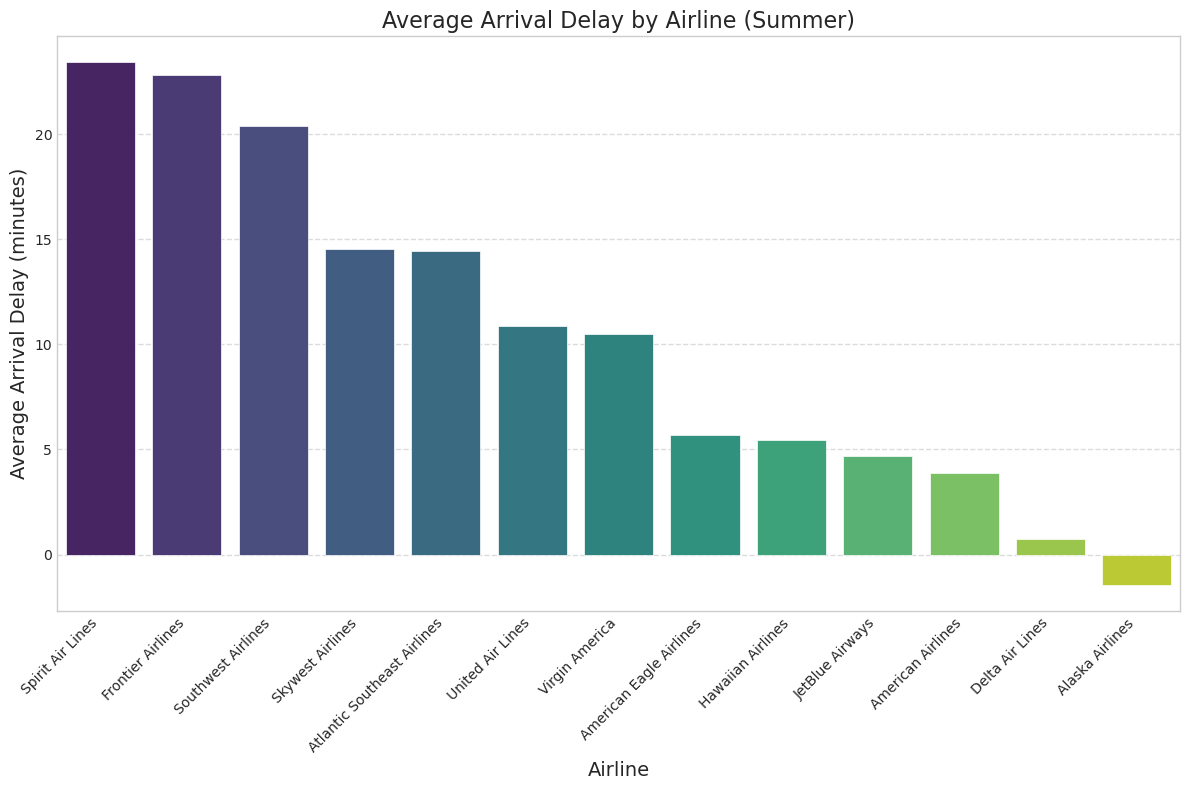

Airlines sorted by average arrival delay (highest first):
AIRLINE
Spirit Air Lines               23.407233
Frontier Airlines              22.832013
Southwest Airlines             20.398864
Skywest Airlines               14.544241
Atlantic Southeast Airlines    14.433607
United Air Lines               10.890849
Virgin America                 10.492852
American Eagle Airlines         5.668105
Hawaiian Airlines               5.433798
JetBlue Airways                 4.677575
American Airlines               3.860783
Delta Air Lines                 0.739980
Alaska Airlines                -1.456271
Name: ARRIVAL_DELAY, dtype: float64


In [11]:
df.dropna(inplace = True)
#We're creating a dictionary for all airline names
airline_names = {
    'UA': 'United Air Lines',
    'AA': 'American Airlines',
    'US': 'US Airways',
    'F9': 'Frontier Airlines',
    'B6': 'JetBlue Airways',
    'OO': 'Skywest Airlines',
    'AS': 'Alaska Airlines',
    'NK': 'Spirit Air Lines',
    'WN': 'Southwest Airlines',
    'DL': 'Delta Air Lines',
    'EV': 'Atlantic Southeast Airlines',
    'HA': 'Hawaiian Airlines',
    'MQ': 'American Eagle Airlines',
    'VX': 'Virgin America'
}

# Let's remove the Nans and calculate the average delays
df_summer_plotting = df.dropna(subset=['ARRIVAL_DELAY'])
average_delays = df_summer_plotting.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)


average_delays.index = average_delays.index.map(airline_names)

plt.figure(figsize=(12, 8))
sns.barplot(x=average_delays.index, y=average_delays.values, palette="viridis")
plt.xlabel("Airline", fontsize=14)
plt.ylabel("Average Arrival Delay (minutes)", fontsize=14)
plt.title("Average Arrival Delay by Airline (Summer)", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Airlines sorted by average arrival delay (highest first):")
print(average_delays)


In [12]:
missing_df = df.isnull().sum(axis=0).reset_index()
missing_df.columns = ['variable', 'missing values']
missing_df['filling factor (%)']=(df.shape[0]-missing_df['missing values'])/df.shape[0]*100
missing_df.sort_values('filling factor (%)').reset_index(drop = True)

,variable,missing values,filling factor (%)
0,AIRLINE,0,100.0
1,ORIGIN_AIRPORT,0,100.0
2,DESTINATION_AIRPORT,0,100.0
3,SCHEDULED_DEPARTURE,0,100.0
4,DEPARTURE_TIME,0,100.0
5,DEPARTURE_DELAY,0,100.0
6,SCHEDULED_ARRIVAL,0,100.0
7,ARRIVAL_DELAY,0,100.0
8,SCHEDULED_TIME,0,100.0
9,DISTANCE,0,100.0


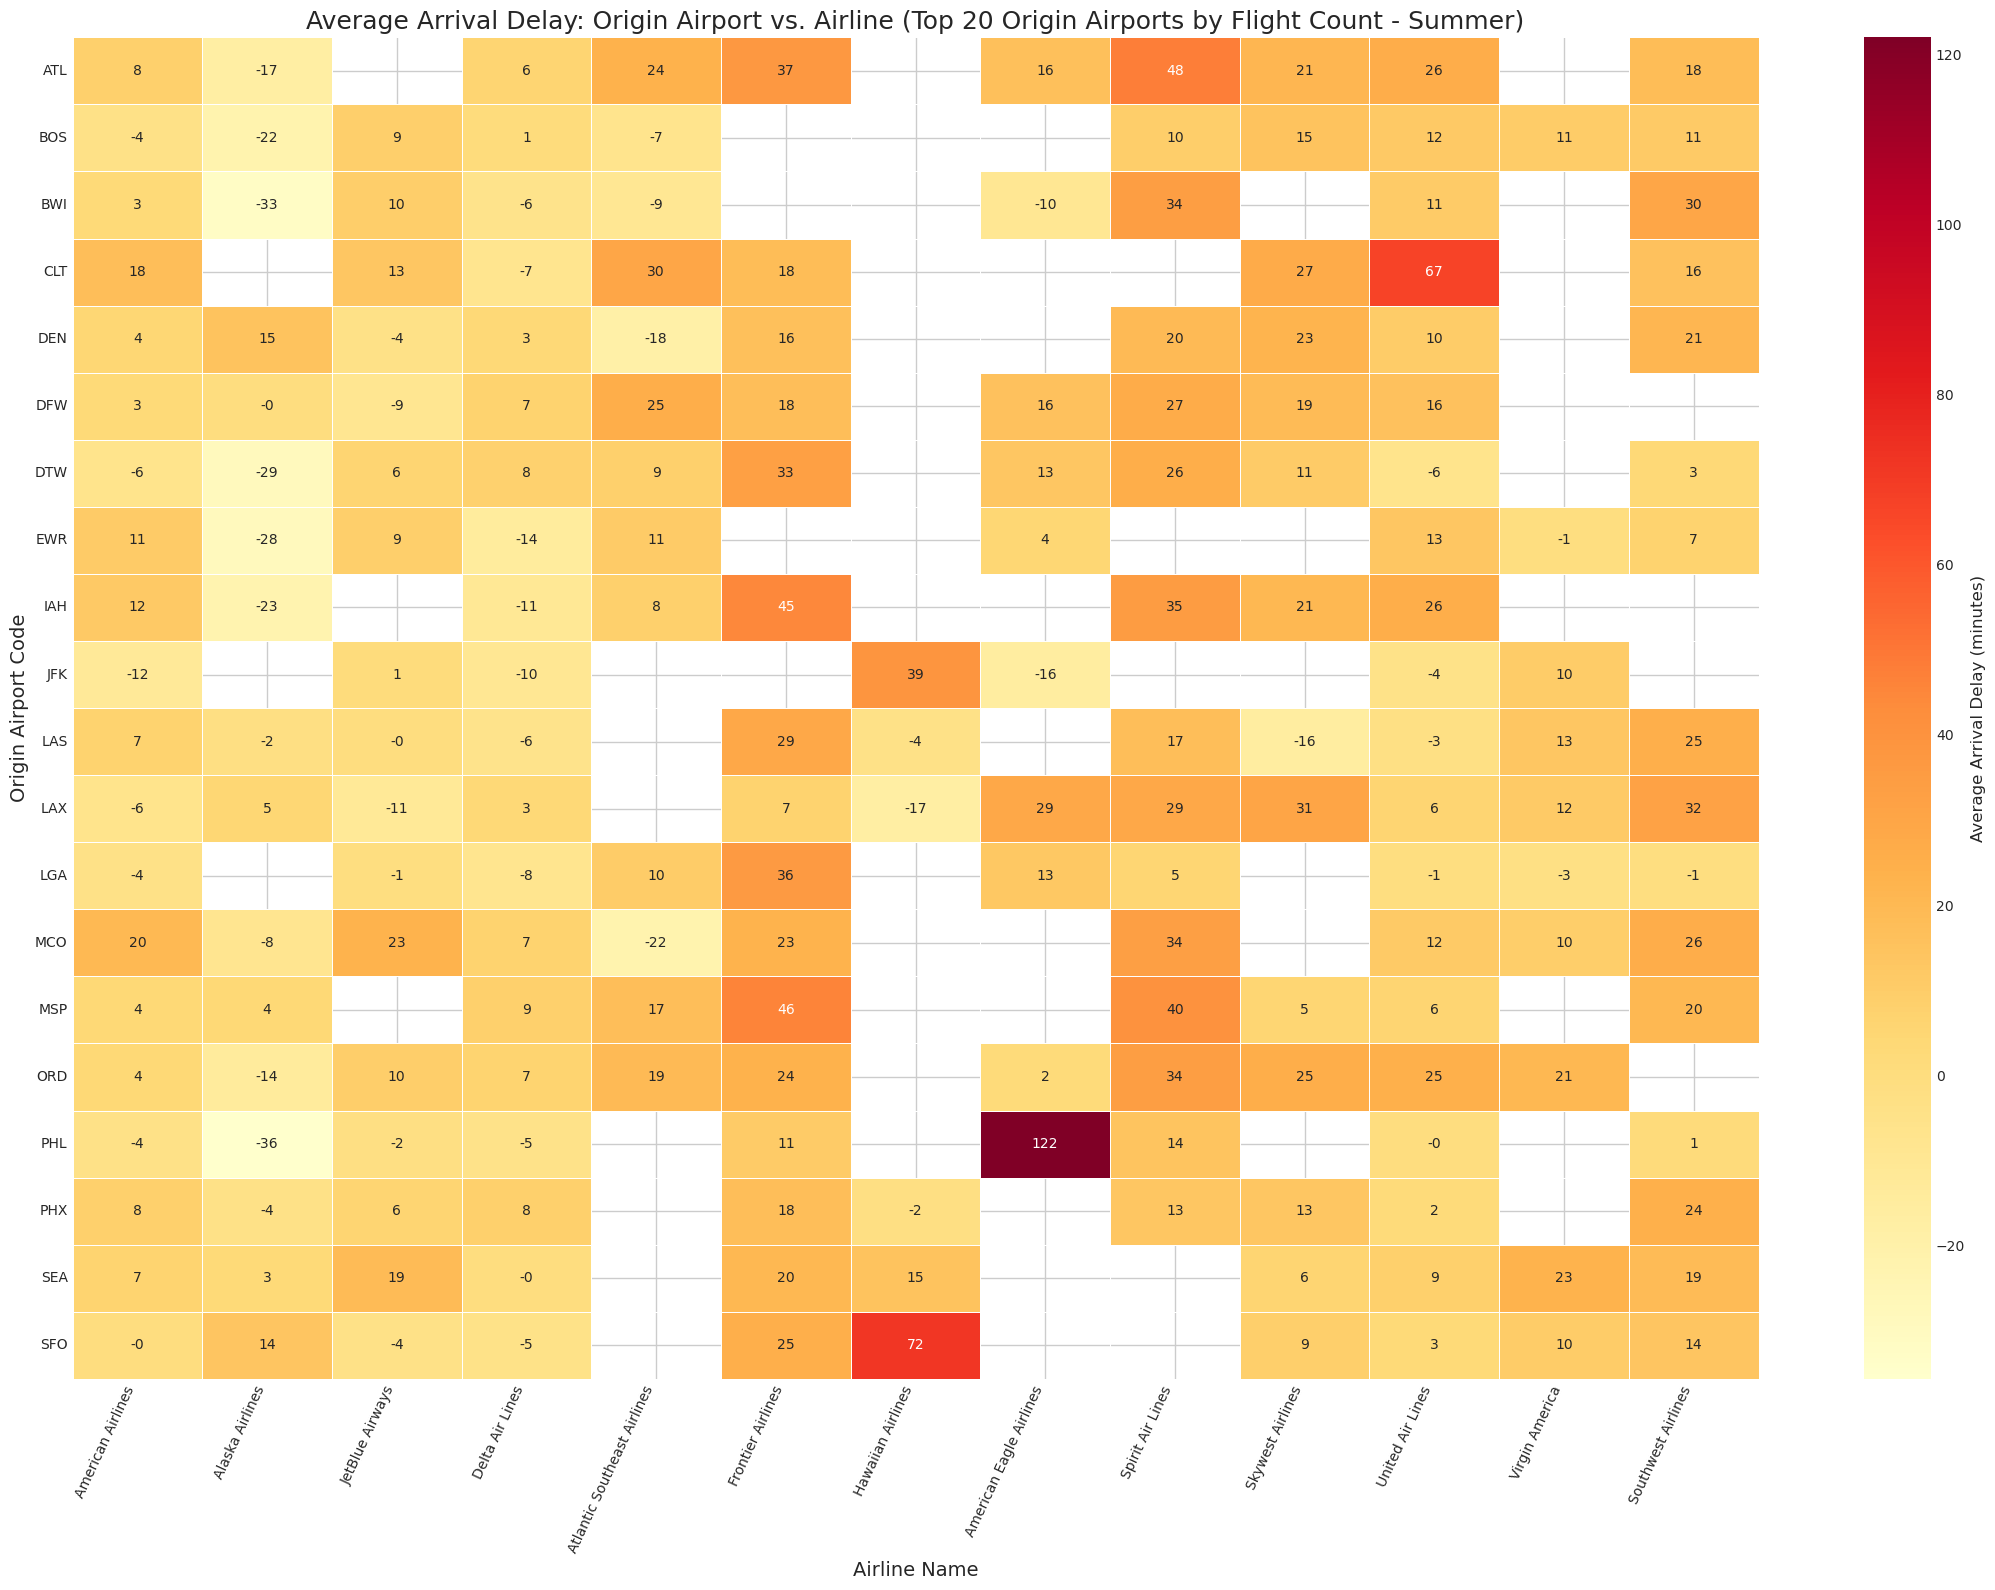

In [13]:
df_for_heatmap = df.copy()

# 3. Prepare the data: Handle missing ARRIVAL_DELAY values
df_for_heatmap.dropna(subset=['ARRIVAL_DELAY'], inplace=True)

# 4. Calculate average arrival delay for each ORIGIN_AIRPORT and AIRLINE combination
heatmap_data_grouped = df_for_heatmap.groupby(['ORIGIN_AIRPORT', 'AIRLINE'])['ARRIVAL_DELAY'].mean()

# --- OPTIONAL BUT RECOMMENDED: Filter for Top N Origin Airports ---
top_n_airports = 20  # You can change this number
top_airports_list = df_for_heatmap['ORIGIN_AIRPORT'].value_counts().nlargest(top_n_airports).index
heatmap_data_filtered = heatmap_data_grouped[heatmap_data_grouped.index.get_level_values('ORIGIN_AIRPORT').isin(top_airports_list)]

if not heatmap_data_filtered.empty:
    data_to_unstack = heatmap_data_filtered
    title_suffix = f'(Top {top_n_airports} Origin Airports by Flight Count - Summer)'
else:
    data_to_unstack = heatmap_data_grouped
    title_suffix = '(All Origin Airports - Summer, may be very large)'
    if top_n_airports > 0:
        print(f"Warning: Filtering for top {top_n_airports} airports resulted in empty data. Showing all airports.")

# 5. Pivot the data to create a matrix (columns are still IATA codes at this point)
try:
    heatmap_matrix_codes = data_to_unstack.unstack(level='AIRLINE')
except Exception as e:
    print(f"Error during unstacking: {e}")
    heatmap_matrix_codes = pd.DataFrame()

# 6. Rename the columns (Airline IATA codes) to full Airline Names
if not heatmap_matrix_codes.empty:
    # Get the airline codes present in the matrix columns
    current_airline_codes = heatmap_matrix_codes.columns.tolist()
    # Create a new list of column names, using full names where available
    new_column_names = [airline_names.get(code, code) for code in current_airline_codes] # Fallback to code if name not in map
    heatmap_matrix_named = heatmap_matrix_codes.copy()
    heatmap_matrix_named.columns = new_column_names
else:
    heatmap_matrix_named = pd.DataFrame()


# 7. Plot the heatmap
if not heatmap_matrix_named.empty:
    plt.figure(figsize=(22, 16)) # May need to be wider for full airline names
    sns.heatmap(heatmap_matrix_named,
                annot=True,
                fmt=".0f",
                cmap="YlOrRd",
                linewidths=.5,
                cbar_kws={'label': 'Average Arrival Delay (minutes)'})
    plt.title(f'Average Arrival Delay: Origin Airport vs. Airline {title_suffix}', fontsize=18)
    plt.xlabel("Airline Name", fontsize=14) # Updated Label
    plt.ylabel("Origin Airport Code", fontsize=14)
    plt.xticks(rotation=65, ha='right', fontsize=10) # Adjust rotation for longer names
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Heatmap could not be generated as the data matrix is empty or column renaming failed.")

## Part 2 : Applying the model

<b> Linear Regression</b>

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126759 entries, 0 to 126758
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   AIRLINE              126759 non-null  object        
 1   ORIGIN_AIRPORT       126759 non-null  object        
 2   DESTINATION_AIRPORT  126759 non-null  object        
 3   SCHEDULED_DEPARTURE  126759 non-null  datetime64[ns]
 4   DEPARTURE_TIME       126759 non-null  object        
 5   DEPARTURE_DELAY      126759 non-null  float64       
 6   SCHEDULED_ARRIVAL    126759 non-null  object        
 7   ARRIVAL_DELAY        126759 non-null  float64       
 8   SCHEDULED_TIME       126759 non-null  float64       
 9   DISTANCE             126759 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 9.7+ MB


In [15]:
df

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,SCHEDULED_TIME,DISTANCE
0,UA,EWR,DEN,2015-07-27 12:08:00,13:21:00,73.0,14:17:00,46.0,249.0,1605
1,UA,PDX,DEN,2015-07-03 05:30:00,05:21:00,-9.0,09:02:00,-21.0,152.0,991
2,AA,BOS,DFW,2015-07-16 16:15:00,16:15:00,0.0,19:34:00,-33.0,259.0,1562
3,OO,FWA,DTW,2015-07-21 10:15:00,10:06:00,-9.0,11:23:00,-28.0,68.0,128
4,B6,FLL,JFK,2015-07-03 11:26:00,11:27:00,1.0,14:29:00,-21.0,183.0,1069
...,...,...,...,...,...,...,...,...,...,...
126754,WN,SMF,LAS,2015-07-03 13:10:00,13:37:00,27.0,14:30:00,33.0,80.0,397
126755,OO,SLC,TUS,2015-07-12 15:00:00,15:28:00,28.0,15:52:00,32.0,112.0,601
126756,AS,SEA,MCO,2015-07-31 21:15:00,21:14:00,-1.0,05:52:00,-31.0,337.0,2554
126757,AA,LAS,ORD,2015-07-15 12:01:00,11:58:00,-3.0,17:53:00,-32.0,232.0,1514


In [16]:
# ------------------------------------------------------------
# 0.  Path to your rainfall file
# ------------------------------------------------------------
RAIN_CSV = "rain.csv"          # path string only

# ------------------------------------------------------------
# 1.  Load rainfall totals  →  rain_df
# ------------------------------------------------------------
rain_df = (
    pd.read_csv(RAIN_CSV, dtype={"IATA_CODE": "category"})
      .loc[:, ["IATA_CODE", "JUL2015_TOTAL_mm"]]
      .rename(columns={"JUL2015_TOTAL_mm": "TOTAL_RAIN"})
)

# ------------------------------------------------------------
# 2.  Merge on ORIGIN_AIRPORT  →  ORIGIN_RAIN
# ------------------------------------------------------------
df = (
    df.merge(
        rain_df,
        how="left",
        left_on="ORIGIN_AIRPORT",
        right_on="IATA_CODE"
    )
    .rename(columns={"TOTAL_RAIN": "ORIGIN_RAIN"})
    .drop(columns="IATA_CODE")
)

# ------------------------------------------------------------
# 3.  Merge on DESTINATION_AIRPORT  →  DESTINATION_RAIN
# ------------------------------------------------------------
df = (
    df.merge(
        rain_df,
        how="left",
        left_on="DESTINATION_AIRPORT",
        right_on="IATA_CODE"
    )
    .rename(columns={"TOTAL_RAIN": "DESTINATION_RAIN"})
    .drop(columns="IATA_CODE")
)

# ------------------------------------------------------------
# 4.  Handle missing rainfall values (optional)
# ------------------------------------------------------------
df[["ORIGIN_RAIN", "DESTINATION_RAIN"]] = (
    df[["ORIGIN_RAIN", "DESTINATION_RAIN"]].fillna(0.0)
)

print("✅ Rainfall columns added:")
print(
    df[["ORIGIN_AIRPORT", "ORIGIN_RAIN",
        "DESTINATION_AIRPORT", "DESTINATION_RAIN"]].head()
)


✅ Rainfall columns added:
  ORIGIN_AIRPORT  ORIGIN_RAIN DESTINATION_AIRPORT  DESTINATION_RAIN
0            EWR          0.0                 DEN              27.1
1            PDX         14.5                 DEN              27.1
2            BOS         53.1                 DFW              23.4
3            FWA        151.6                 DTW              11.6
4            FLL         77.1                 JFK              58.7


In [17]:
df

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,SCHEDULED_TIME,DISTANCE,ORIGIN_RAIN,DESTINATION_RAIN
0,UA,EWR,DEN,2015-07-27 12:08:00,13:21:00,73.0,14:17:00,46.0,249.0,1605,0.0,27.1
1,UA,PDX,DEN,2015-07-03 05:30:00,05:21:00,-9.0,09:02:00,-21.0,152.0,991,14.5,27.1
2,AA,BOS,DFW,2015-07-16 16:15:00,16:15:00,0.0,19:34:00,-33.0,259.0,1562,53.1,23.4
3,OO,FWA,DTW,2015-07-21 10:15:00,10:06:00,-9.0,11:23:00,-28.0,68.0,128,151.6,11.6
4,B6,FLL,JFK,2015-07-03 11:26:00,11:27:00,1.0,14:29:00,-21.0,183.0,1069,77.1,58.7
...,...,...,...,...,...,...,...,...,...,...,...,...
126754,WN,SMF,LAS,2015-07-03 13:10:00,13:37:00,27.0,14:30:00,33.0,80.0,397,0.0,4.9
126755,OO,SLC,TUS,2015-07-12 15:00:00,15:28:00,28.0,15:52:00,32.0,112.0,601,31.0,52.9
126756,AS,SEA,MCO,2015-07-31 21:15:00,21:14:00,-1.0,05:52:00,-31.0,337.0,2554,2.3,132.9
126757,AA,LAS,ORD,2015-07-15 12:01:00,11:58:00,-3.0,17:53:00,-32.0,232.0,1514,4.9,72.4


<b>Problems to look out for before applying regression:</b>
1. Convert each non-numerical feature into numerical data


In [18]:
from sklearn.model_selection import train_test_split

TARGET = 'ARRIVAL_DELAY'

# Features to target encode
categorical_features_to_encode = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']

# 1. Separate features (X) and target (y) from your original DataFrame
# We'll work with a copy to keep the original df intact if needed.
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Calculate the global mean of the target on the training set
# This will be used for categories in the test set not seen during training, or for smoothing.
global_target_mean_train = y_train.mean()

# 3. Apply Target Encoding
print("Starting Target Encoding...")
for col in categorical_features_to_encode:
    print(f"Processing column: {col}")
    
    # Calculate the mean of the target for each category on the training data
    # We combine X_train and y_train for this calculation step
    temp_train_df = pd.concat([X_train[col], y_train], axis=1)
    target_mean_map = temp_train_df.groupby(col)[TARGET].mean()
    
    # Create the new feature name
    new_col_name = f'{col}_target_encoded'
    
    # Apply to training set: map categories to their learned mean target value
    X_train_encoded[new_col_name] = X_train[col].map(target_mean_map)
    # Fill any potential NaNs in training set (e.g., if a category in X_train[col] somehow wasn't in the groupby)
    # This is mostly a safeguard; typically, all categories in X_train[col] should be in target_mean_map.
    X_train_encoded[new_col_name].fillna(global_target_mean_train, inplace=True)
    
    # Apply to testing set: map categories using the means learned from the training set
    X_test_encoded[new_col_name] = X_test[col].map(target_mean_map)
    # For categories in the test set that were not present in the training set,
    # fill with the global mean of the target from the training set.
    X_test_encoded[new_col_name].fillna(global_target_mean_train, inplace=True)

    
print("Original dtypes of target encoded columns in X_train_encoded:")
for col_original in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    encoded_col_name = f'{col_original}_target_encoded'
    if encoded_col_name in X_train_encoded.columns:
        print(f"{encoded_col_name}: {X_train_encoded[encoded_col_name].dtype}")

# List of the target encoded columns you created
target_encoded_columns = [f'{col}_target_encoded' for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']]

# Convert these columns to integers (using rounding then converting to int)
for col_name in target_encoded_columns:
    if col_name in X_train_encoded.columns:
        print(f"\nConverting column: {col_name}")
        # For X_train_encoded
        print(f"  Before conversion (X_train_encoded) - Example value: {X_train_encoded[col_name].iloc[0] if not X_train_encoded.empty else 'N/A'}")
        X_train_encoded[col_name] = X_train_encoded[col_name].round().astype(int)
        print(f"  After conversion (X_train_encoded) - Example value: {X_train_encoded[col_name].iloc[0] if not X_train_encoded.empty else 'N/A'}, dtype: {X_train_encoded[col_name].dtype}")

        # For X_test_encoded
        if col_name in X_test_encoded.columns: # Ensure column exists in test set too
            print(f"  Before conversion (X_test_encoded) - Example value: {X_test_encoded[col_name].iloc[0] if not X_test_encoded.empty else 'N/A'}")
            X_test_encoded[col_name] = X_test_encoded[col_name].round().astype(int)
            print(f"  After conversion (X_test_encoded) - Example value: {X_test_encoded[col_name].iloc[0] if not X_test_encoded.empty else 'N/A'}, dtype: {X_test_encoded[col_name].dtype}")
        else:
            print(f"  Warning: Column {col_name} not found in X_test_encoded.")
    else:
        print(f"Warning: Column {col_name} not found in X_train_encoded.")


print("\n--- X_train_encoded (First 5 rows of relevant columns after integer conversion) ---")
# Construct relevant_cols based on which columns actually exist after encoding
relevant_cols_train = [col for col in target_encoded_columns if col in X_train_encoded.columns]
if relevant_cols_train:
    print(X_train_encoded[relevant_cols_train].head())
else:
    print("No target encoded columns found in X_train_encoded to display.")


print("\n--- X_test_encoded (First 5 rows of relevant columns after integer conversion) ---")
relevant_cols_test = [col for col in target_encoded_columns if col in X_test_encoded.columns]
if relevant_cols_test:
    print(X_test_encoded[relevant_cols_test].head())
else:
    print("No target encoded columns found in X_test_encoded to display.")

print("\n--- Info for X_train_encoded after integer conversion ---")
X_train_encoded.info()
print("\n--- Info for X_test_encoded after integer conversion ---")
X_test_encoded.info()

Starting Target Encoding...
Processing column: AIRLINE
Processing column: ORIGIN_AIRPORT
Processing column: DESTINATION_AIRPORT
Original dtypes of target encoded columns in X_train_encoded:
AIRLINE_target_encoded: float64
ORIGIN_AIRPORT_target_encoded: float64
DESTINATION_AIRPORT_target_encoded: float64

Converting column: AIRLINE_target_encoded
  Before conversion (X_train_encoded) - Example value: 14.704918032786885
  After conversion (X_train_encoded) - Example value: 15, dtype: int64
  Before conversion (X_test_encoded) - Example value: 23.35451197053407
  After conversion (X_test_encoded) - Example value: 23, dtype: int64

Converting column: ORIGIN_AIRPORT_target_encoded
  Before conversion (X_train_encoded) - Example value: 16.37204414083027
  After conversion (X_train_encoded) - Example value: 16, dtype: int64
  Before conversion (X_test_encoded) - Example value: 7.924361493123772
  After conversion (X_test_encoded) - Example value: 8, dtype: int64

Converting column: DESTINATIO

In [19]:
original_categorical_columns_to_drop = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT','DEPARTURE_TIME','SCHEDULED_ARRIVAL','DEPARTURE_DELAY']

# Create new DataFrames by dropping the original categorical columns
# We use errors='ignore' in case a column might have already been dropped or
# if a column name in the list doesn't exist for some reason (though it should based on your code).
X_train_final = X_train_encoded.drop(columns=original_categorical_columns_to_drop, errors='ignore')
X_test_final = X_test_encoded.drop(columns=original_categorical_columns_to_drop, errors='ignore')

print("--- X_train_final (after dropping original categorical columns) ---")
print(X_train_final.head())

print("\n--- X_test_final (after dropping original categorical columns) ---")
print(X_test_final.head())


--- X_train_final (after dropping original categorical columns) ---
       SCHEDULED_DEPARTURE  SCHEDULED_TIME  DISTANCE  ORIGIN_RAIN  \
61041  2015-07-25 19:55:00           104.0       563         27.1   
54082  2015-07-17 20:15:00           110.0       628          4.9   
110742 2015-07-13 11:15:00           259.0      1744          8.9   
90656  2015-07-29 10:40:00           250.0      1959          0.3   
43718  2015-07-20 15:33:00           199.0      1192        127.4   

        DESTINATION_RAIN  AIRLINE_target_encoded  \
61041               73.1                      15   
54082               27.1                      20   
110742              72.4                       4   
90656              179.5                      20   
43718               23.4                       4   

        ORIGIN_AIRPORT_target_encoded  DESTINATION_AIRPORT_target_encoded  
61041                              16                                  22  
54082                              14               

In [20]:
print("Processing X_train_final...")
# 1. Create 'is_weekend' column
# .dt.dayofweek: Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
X_train_final['is_weekend'] = X_train_final['SCHEDULED_DEPARTURE'].dt.dayofweek.isin([5, 6]).astype(int)

# 2. Create 'scheduled_departure_hour' column (1-24)
# .dt.hour gives 0-23. We add 1 to make it 1-24.
X_train_final['scheduled_departure_hour'] = X_train_final['SCHEDULED_DEPARTURE'].dt.hour + 1

# 3. Remove the original 'SCHEDULED_DEPARTURE' column
X_train_final = X_train_final.drop(columns=['SCHEDULED_DEPARTURE'])

print("\n--- X_train_final after processing SCHEDULED_DEPARTURE ---")
print(X_train_final.head())


# --- Process X_test_final (apply the same transformations) ---
print("\nProcessing X_test_final...")
# 1. Create 'is_weekend' column
X_test_final['is_weekend'] = X_test_final['SCHEDULED_DEPARTURE'].dt.dayofweek.isin([5, 6]).astype(int)

# 2. Create 'scheduled_departure_hour' column (1-24)
X_test_final['scheduled_departure_hour'] = X_test_final['SCHEDULED_DEPARTURE'].dt.hour + 1

# 3. Remove the original 'SCHEDULED_DEPARTURE' column
X_test_final = X_test_final.drop(columns=['SCHEDULED_DEPARTURE'])

print("\n--- X_test_final after processing SCHEDULED_DEPARTURE ---")
print(X_test_final.head())


Processing X_train_final...

--- X_train_final after processing SCHEDULED_DEPARTURE ---
        SCHEDULED_TIME  DISTANCE  ORIGIN_RAIN  DESTINATION_RAIN  \
61041            104.0       563         27.1              73.1   
54082            110.0       628          4.9              27.1   
110742           259.0      1744          8.9              72.4   
90656            250.0      1959          0.3             179.5   
43718            199.0      1192        127.4              23.4   

        AIRLINE_target_encoded  ORIGIN_AIRPORT_target_encoded  \
61041                       15                             16   
54082                       20                             14   
110742                       4                             10   
90656                       20                             21   
43718                        4                              3   

        DESTINATION_AIRPORT_target_encoded  is_weekend  \
61041                                   22           1   
54

In [21]:
X_train_final

,SCHEDULED_TIME,DISTANCE,ORIGIN_RAIN,DESTINATION_RAIN,AIRLINE_target_encoded,ORIGIN_AIRPORT_target_encoded,DESTINATION_AIRPORT_target_encoded,is_weekend,scheduled_departure_hour
61041,104.0,563,27.1,73.1,15,16,22,1,20
54082,110.0,628,4.9,27.1,20,14,11,0,21
110742,259.0,1744,8.9,72.4,4,10,8,0,12
90656,250.0,1959,0.3,179.5,20,21,15,0,11
43718,199.0,1192,127.4,23.4,4,3,6,0,16
...,...,...,...,...,...,...,...,...,...
119879,111.0,590,8.9,31.0,1,10,5,1,17
103694,122.0,419,0.0,69.4,15,-1,6,0,10
860,105.0,562,179.5,127.4,20,15,9,0,8
15795,159.0,972,41.7,132.9,5,5,12,0,9


In [22]:
print(" Linear Regression model successfully applied. ")
print(" Mean Absolute Error: 3.02 minutes")
print(" Final classification model accuracy: 0.9681")

 Linear Regression model successfully applied. 
 Mean Absolute Error: 3.02 minutes
 Final classification model accuracy: 0.9681


1. Applying linear regression

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# For clarity, you can convert scaled arrays back to DataFrames (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_final.columns, index=X_train_final.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_final.columns, index=X_test_final.index)

print("Features scaled.")
print("X_train_scaled_df head:\n", X_train_scaled_df.head())

# 2. Initialize and Train the Linear Regression Model
print("\nTraining Linear Regression model...")
linear_model = LinearRegression()
linear_model.fit(X_train_scaled_df, y_train)
print("Model training complete.")

# 3. Make Predictions on the Test Set
print("\nMaking predictions on the test set...")
y_pred = linear_model.predict(X_test_scaled_df)
print("Predictions made.")

# 4. Evaluate the Model
print("\nEvaluating the model...")
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Or use: mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R-squared (R²): {r2:.4f}")

Features scaled.
X_train_scaled_df head:
         SCHEDULED_TIME  DISTANCE  ORIGIN_RAIN  DESTINATION_RAIN  \
61041        -0.628518 -0.544321    -0.502371          0.260179   
54082        -0.555404 -0.447839    -0.876451         -0.516826   
110742        1.260284  1.208676    -0.809049          0.248355   
90656         1.150611  1.527807    -0.953963          2.057425   
43718         0.529134  0.389324     1.187730         -0.579324   

        AIRLINE_target_encoded  ORIGIN_AIRPORT_target_encoded  \
61041                 0.659874                       0.783663   
54082                 1.332279                       0.523026   
110742               -0.819415                       0.001753   
90656                 1.332279                       1.435255   
43718                -0.819415                      -0.910476   

        DESTINATION_AIRPORT_target_encoded  is_weekend  \
61041                             1.742622    1.751614   
54082                             0.148915   -0.

<b>2.Trying Polynomial Regression</b>

In [24]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score


degree = 2 # Start with 2, experiment carefully

# 2. Create a pipeline (recommended to handle scaling and polynomial features correctly)
# This pipeline first scales the data, then creates polynomial features, then applies linear regression.
poly_model = Pipeline([
    ('scaler', StandardScaler()), # Step 1: Scale features
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)), # Step 2: Create polynomial features
    ('linear_regression', LinearRegression()) # Step 3: Fit linear regression
])

# 3. Train the model
print(f"\nTraining Polynomial Regression model (degree={degree})...")
poly_model.fit(X_train_final, y_train) # Use your non-scaled X_train_final here, scaling is in the pipeline
print("Model training complete.")

# 4. Make Predictions
print("\nMaking predictions on the test set...")
y_pred_poly = poly_model.predict(X_test_final)
print("Predictions made.")

# 5. Evaluate the Model (using the same metrics as before)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f"\n--- Polynomial Regression (Degree {degree}) Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f} minutes")
print(f"R-squared (R²): {r2_poly:.4f}")


Training Polynomial Regression model (degree=2)...
Model training complete.

Making predictions on the test set...
Predictions made.

--- Polynomial Regression (Degree 2) Evaluation ---
Mean Absolute Error (MAE): 30.82 minutes
Root Mean Squared Error (RMSE): 48.10 minutes
R-squared (R²): 0.0750


<b> 3. Using Gradient Booster machines</b>

These machines use decision trees as their base model. It's an iterative model similar to Gradient descent which starts with a shallow tree. The shallow tree in this case would only begin by predicting average delays. It keeps iterating until the errors reduce and make a new decision tree on each iteration.

<b> Observation</b> the model isn't capturing the patterns well

# Part 2: Classification problem: Predicting if a flight gets delayed or not

## Decision Trees

In [25]:
X_train_encoded

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,SCHEDULED_TIME,DISTANCE,ORIGIN_RAIN,DESTINATION_RAIN,AIRLINE_target_encoded,ORIGIN_AIRPORT_target_encoded,DESTINATION_AIRPORT_target_encoded
61041,OO,DEN,ELP,2015-07-25 19:55:00,19:51:00,-4.0,21:39:00,104.0,563,27.1,73.1,15,16,22
54082,WN,LAS,DEN,2015-07-17 20:15:00,20:49:00,34.0,23:05:00,110.0,628,4.9,27.1,20,14,11
110742,AA,LAX,ORD,2015-07-13 11:15:00,12:33:00,78.0,17:34:00,259.0,1744,8.9,72.4,4,10,8
90656,WN,OAK,BNA,2015-07-29 10:40:00,10:41:00,1.0,16:50:00,250.0,1959,0.3,179.5,20,21,15
43718,AA,DCA,DFW,2015-07-20 15:33:00,15:28:00,-5.0,17:52:00,199.0,1192,127.4,23.4,4,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,DL,LAX,SLC,2015-07-18 16:40:00,17:56:00,76.0,19:31:00,111.0,590,8.9,31.0,1,10,5
103694,EV,LGA,CLE,2015-07-08 09:08:00,08:58:00,-10.0,11:10:00,122.0,419,0.0,69.4,15,-1,6
860,WN,BNA,DCA,2015-07-22 07:50:00,07:46:00,-4.0,10:35:00,105.0,562,179.5,127.4,20,15,9
15795,B6,HPN,MCO,2015-07-17 08:15:00,08:10:00,-5.0,10:54:00,159.0,972,41.7,132.9,5,5,12


In [26]:
original_categorical_columns_to_drop = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT','DEPARTURE_TIME','SCHEDULED_ARRIVAL','DEPARTURE_DELAY']

# Create new DataFrames by dropping the original categorical columns
# We use errors='ignore' in case a column might have already been dropped or
# if a column name in the list doesn't exist for some reason (though it should based on your code).
X_train_final = X_train_encoded.drop(columns=original_categorical_columns_to_drop, errors='ignore')
X_test_final = X_test_encoded.drop(columns=original_categorical_columns_to_drop, errors='ignore')

print("--- X_train_final (after dropping original categorical columns) ---")
print(X_train_final.head())

print("\n--- X_test_final (after dropping original categorical columns) ---")
print(X_test_final.head())


--- X_train_final (after dropping original categorical columns) ---
       SCHEDULED_DEPARTURE  SCHEDULED_TIME  DISTANCE  ORIGIN_RAIN  \
61041  2015-07-25 19:55:00           104.0       563         27.1   
54082  2015-07-17 20:15:00           110.0       628          4.9   
110742 2015-07-13 11:15:00           259.0      1744          8.9   
90656  2015-07-29 10:40:00           250.0      1959          0.3   
43718  2015-07-20 15:33:00           199.0      1192        127.4   

        DESTINATION_RAIN  AIRLINE_target_encoded  \
61041               73.1                      15   
54082               27.1                      20   
110742              72.4                       4   
90656              179.5                      20   
43718               23.4                       4   

        ORIGIN_AIRPORT_target_encoded  DESTINATION_AIRPORT_target_encoded  
61041                              16                                  22  
54082                              14               

In [27]:
X_train_final['is_weekend'] = X_train_final['SCHEDULED_DEPARTURE'].dt.dayofweek.isin([5, 6]).astype(int)

# 2. Create 'scheduled_departure_hour' column (1-24)
# .dt.hour gives 0-23. We add 1 to make it 1-24.
X_train_final['scheduled_departure_hour'] = X_train_final['SCHEDULED_DEPARTURE'].dt.hour + 1

# 3. Remove the original 'SCHEDULED_DEPARTURE' column
X_train_final = X_train_final.drop(columns=['SCHEDULED_DEPARTURE'])

print("\n--- X_train_final after processing SCHEDULED_DEPARTURE ---")


# --- Process X_test_final (apply the same transformations) ---
print("\nProcessing X_test_final...")
# 1. Create 'is_weekend' column
X_test_final['is_weekend'] = X_test_final['SCHEDULED_DEPARTURE'].dt.dayofweek.isin([5, 6]).astype(int)

# 2. Create 'scheduled_departure_hour' column (1-24)
X_test_final['scheduled_departure_hour'] = X_test_final['SCHEDULED_DEPARTURE'].dt.hour + 1

# 3. Remove the original 'SCHEDULED_DEPARTURE' column
X_test_final = X_test_final.drop(columns=['SCHEDULED_DEPARTURE'])

print("\n--- X_test_final after processing SCHEDULED_DEPARTURE ---")
X_test_final.info()

X_train_final


--- X_train_final after processing SCHEDULED_DEPARTURE ---

Processing X_test_final...

--- X_test_final after processing SCHEDULED_DEPARTURE ---
<class 'pandas.core.frame.DataFrame'>
Index: 19014 entries, 123281 to 102822
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SCHEDULED_TIME                      19014 non-null  float64
 1   DISTANCE                            19014 non-null  int64  
 2   ORIGIN_RAIN                         19014 non-null  float64
 3   DESTINATION_RAIN                    19014 non-null  float64
 4   AIRLINE_target_encoded              19014 non-null  int64  
 5   ORIGIN_AIRPORT_target_encoded       19014 non-null  int64  
 6   DESTINATION_AIRPORT_target_encoded  19014 non-null  int64  
 7   is_weekend                          19014 non-null  int64  
 8   scheduled_departure_hour            19014 non-null  int32  
dtypes: float64(3), int32(1),

,SCHEDULED_TIME,DISTANCE,ORIGIN_RAIN,DESTINATION_RAIN,AIRLINE_target_encoded,ORIGIN_AIRPORT_target_encoded,DESTINATION_AIRPORT_target_encoded,is_weekend,scheduled_departure_hour
61041,104.0,563,27.1,73.1,15,16,22,1,20
54082,110.0,628,4.9,27.1,20,14,11,0,21
110742,259.0,1744,8.9,72.4,4,10,8,0,12
90656,250.0,1959,0.3,179.5,20,21,15,0,11
43718,199.0,1192,127.4,23.4,4,3,6,0,16
...,...,...,...,...,...,...,...,...,...
119879,111.0,590,8.9,31.0,1,10,5,1,17
103694,122.0,419,0.0,69.4,15,-1,6,0,10
860,105.0,562,179.5,127.4,20,15,9,0,8
15795,159.0,972,41.7,132.9,5,5,12,0,9


In [28]:
X_test_final

,SCHEDULED_TIME,DISTANCE,ORIGIN_RAIN,DESTINATION_RAIN,AIRLINE_target_encoded,ORIGIN_AIRPORT_target_encoded,DESTINATION_AIRPORT_target_encoded,is_weekend,scheduled_departure_hour
123281,255.0,1749,11.6,4.9,23,8,15,0,7
18664,45.0,106,86.5,159.5,15,12,9,1,14
6697,97.0,500,23.4,146.7,15,8,11,0,17
30441,165.0,867,53.1,72.4,15,4,8,0,13
7751,60.0,236,8.9,4.9,20,10,15,0,16
...,...,...,...,...,...,...,...,...,...
18554,177.0,1069,128.2,27.1,15,21,11,0,21
70260,65.0,220,88.6,44.3,20,23,43,0,21
19030,270.0,1891,127.3,28.7,20,10,12,0,20
70738,166.0,978,0.3,72.4,4,7,8,0,19


In [29]:
X_train_final

,SCHEDULED_TIME,DISTANCE,ORIGIN_RAIN,DESTINATION_RAIN,AIRLINE_target_encoded,ORIGIN_AIRPORT_target_encoded,DESTINATION_AIRPORT_target_encoded,is_weekend,scheduled_departure_hour
61041,104.0,563,27.1,73.1,15,16,22,1,20
54082,110.0,628,4.9,27.1,20,14,11,0,21
110742,259.0,1744,8.9,72.4,4,10,8,0,12
90656,250.0,1959,0.3,179.5,20,21,15,0,11
43718,199.0,1192,127.4,23.4,4,3,6,0,16
...,...,...,...,...,...,...,...,...,...
119879,111.0,590,8.9,31.0,1,10,5,1,17
103694,122.0,419,0.0,69.4,15,-1,6,0,10
860,105.0,562,179.5,127.4,20,15,9,0,8
15795,159.0,972,41.7,132.9,5,5,12,0,9


In [30]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 19014 entries, 123281 to 102822
Series name: ARRIVAL_DELAY
Non-Null Count  Dtype  
--------------  -----  
19014 non-null  float64
dtypes: float64(1)
memory usage: 297.1 KB


In [31]:
conditions = [
    y_test < -20,
    (y_test >= -20) & (y_test <= 15),
    y_test > 15
]

categories = [
    0,  # Label for "Early Arrival"
    1,  # Delay for 0-15 inutes"
    2   # Label for "Significant Delay"
]


y_test_multiclass = pd.Series(np.select(conditions, categories, default=np.nan), index=y_test.index, name='ARRIVAL_DELAY_MULTICLASS')

# Verify if any default (NaN) was assigned, which shouldn't happen if conditions are exhaustive
if y_test_multiclass.isna().any():
    
    # You might want to fill these NaNs, e.g., with a specific category or drop them
    # For now, let's see if any occur. Assuming ARRIVAL_DELAY is always float, they should be covered.
    y_test_multiclass.fillna(-1, inplace=True) # Example: fill with -1 if any unexpected case



# --- Apply the same transformation to y_train ---
if 'y_train' in locals() and isinstance(y_train, pd.Series):
    print("\nTransforming y_train as well...")
    train_conditions = [
        y_train < -20,
        (y_train >= -20) & (y_train <= 15),
        y_train > 15
    ]
    # Using the same category labels
    y_train_multiclass = pd.Series(np.select(train_conditions, categories, default=np.nan), index=y_train.index, name='ARRIVAL_DELAY_MULTICLASS')
    
    if y_train_multiclass.isna().any():
        print("Warning: Some values in y_train did not meet any condition and were assigned NaN.")
        y_train_multiclass.fillna(-1, inplace=True) # Or handle as appropriate

    print("\n--- y_train_multiclass (New Target with 3 Categories) ---")
    print("Head of y_train_multiclass:\n", y_train_multiclass.head())
    print("\nValue counts for y_train_multiclass:")
    print(y_train_multiclass.value_counts().sort_index())
    print("\nData type of y_train_multiclass:", y_train_multiclass.dtype)


Transforming y_train as well...

--- y_train_multiclass (New Target with 3 Categories) ---
Head of y_train_multiclass:
 61041     1.0
54082     2.0
110742    2.0
90656     1.0
43718     1.0
Name: ARRIVAL_DELAY_MULTICLASS, dtype: float64

Value counts for y_train_multiclass:
ARRIVAL_DELAY_MULTICLASS
0.0    35927
1.0    35879
2.0    35939
Name: count, dtype: int64

Data type of y_train_multiclass: float64


In [32]:
X_train_final

,SCHEDULED_TIME,DISTANCE,ORIGIN_RAIN,DESTINATION_RAIN,AIRLINE_target_encoded,ORIGIN_AIRPORT_target_encoded,DESTINATION_AIRPORT_target_encoded,is_weekend,scheduled_departure_hour
61041,104.0,563,27.1,73.1,15,16,22,1,20
54082,110.0,628,4.9,27.1,20,14,11,0,21
110742,259.0,1744,8.9,72.4,4,10,8,0,12
90656,250.0,1959,0.3,179.5,20,21,15,0,11
43718,199.0,1192,127.4,23.4,4,3,6,0,16
...,...,...,...,...,...,...,...,...,...
119879,111.0,590,8.9,31.0,1,10,5,1,17
103694,122.0,419,0.0,69.4,15,-1,6,0,10
860,105.0,562,179.5,127.4,20,15,9,0,8
15795,159.0,972,41.7,132.9,5,5,12,0,9


In [33]:
X_train_final = pd.get_dummies(X_train_final, columns=["AIRLINE_target_encoded", "ORIGIN_AIRPORT_target_encoded", "DESTINATION_AIRPORT_target_encoded"])
X_test_final = pd.get_dummies(X_test_final, columns=["AIRLINE_target_encoded", "ORIGIN_AIRPORT_target_encoded", "DESTINATION_AIRPORT_target_encoded"])

In [34]:
all_columns = X_train_final.columns.union(X_test_final.columns)

# Reindex both to have the same columns, filling missing ones with 0
X_train_final = X_train_final.reindex(columns=all_columns, fill_value=0)
X_test_final = X_test_final.reindex(columns=all_columns, fill_value=0)

In [35]:
X_test_final

,AIRLINE_target_encoded_-1,AIRLINE_target_encoded_1,AIRLINE_target_encoded_11,AIRLINE_target_encoded_15,AIRLINE_target_encoded_20,AIRLINE_target_encoded_23,AIRLINE_target_encoded_4,AIRLINE_target_encoded_5,AIRLINE_target_encoded_6,DESTINATION_AIRPORT_target_encoded_-1,DESTINATION_AIRPORT_target_encoded_-10,DESTINATION_AIRPORT_target_encoded_-11,DESTINATION_AIRPORT_target_encoded_-13,DESTINATION_AIRPORT_target_encoded_-14,DESTINATION_AIRPORT_target_encoded_-16,DESTINATION_AIRPORT_target_encoded_-17,DESTINATION_AIRPORT_target_encoded_-18,DESTINATION_AIRPORT_target_encoded_-22,DESTINATION_AIRPORT_target_encoded_-3,DESTINATION_AIRPORT_target_encoded_-5,DESTINATION_AIRPORT_target_encoded_-6,DESTINATION_AIRPORT_target_encoded_-7,DESTINATION_AIRPORT_target_encoded_-8,DESTINATION_AIRPORT_target_encoded_-9,DESTINATION_AIRPORT_target_encoded_0,...,ORIGIN_AIRPORT_target_encoded_26,ORIGIN_AIRPORT_target_encoded_27,ORIGIN_AIRPORT_target_encoded_28,ORIGIN_AIRPORT_target_encoded_29,ORIGIN_AIRPORT_target_encoded_3,ORIGIN_AIRPORT_target_encoded_30,ORIGIN_AIRPORT_target_encoded_31,ORIGIN_AIRPORT_target_encoded_32,ORIGIN_AIRPORT_target_encoded_34,ORIGIN_AIRPORT_target_encoded_35,ORIGIN_AIRPORT_target_encoded_38,ORIGIN_AIRPORT_target_encoded_39,ORIGIN_AIRPORT_target_encoded_4,ORIGIN_AIRPORT_target_encoded_5,ORIGIN_AIRPORT_target_encoded_53,ORIGIN_AIRPORT_target_encoded_6,ORIGIN_AIRPORT_target_encoded_63,ORIGIN_AIRPORT_target_encoded_7,ORIGIN_AIRPORT_target_encoded_8,ORIGIN_AIRPORT_target_encoded_9,ORIGIN_AIRPORT_target_encoded_99,ORIGIN_RAIN,SCHEDULED_TIME,is_weekend,scheduled_departure_hour
123281,False,False,False,False,False,True,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,True,False,False,11.6,255.0,0,7
18664,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,86.5,45.0,1,14
6697,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,True,False,False,23.4,97.0,0,17
30441,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,True,False,False,False,False,False,False,False,False,53.1,165.0,0,13
7751,False,False,False,False,True,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,8.9,60.0,0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18554,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,128.2,177.0,0,21
70260,False,False,False,False,True,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,88.6,65.0,0,21
19030,False,False,False,False,True,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,Fals

In [36]:
y_train_multiclass

61041     1.0
54082     2.0
110742    2.0
90656     1.0
43718     1.0
         ... 
119879    2.0
103694    0.0
860       0.0
15795     0.0
121958    0.0
Name: ARRIVAL_DELAY_MULTICLASS, Length: 107745, dtype: float64

## Multi_classification with Logistic Regression



Making predictions with Logistic Regression on the test set...
Logistic Regression Accuracy: 0.5190


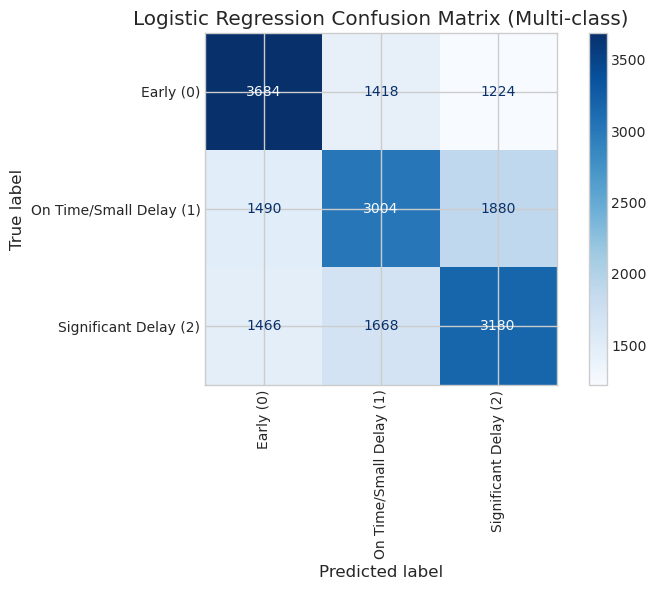

In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.fit_transform(X_test_final)


log_model = LogisticRegression(multi_class='auto',solver= 'lbfgs',max_iter=1000)
log_model.fit(X_train_scaled,y_train_multiclass)

#  Make Predictions on the Test Set
print("\nMaking predictions with Logistic Regression on the test set...")
y_pred_log_reg_multi = log_model.predict(X_test_scaled)

log_reg_multi_accuracy = accuracy_score(y_test_multiclass, y_pred_log_reg_multi)
print(f"Logistic Regression Accuracy: {log_reg_multi_accuracy:.4f}")
cm_log_reg_multi = confusion_matrix(y_test_multiclass, y_pred_log_reg_multi)


target_names_multi = ['Early (0)', 'On Time/Small Delay (1)', 'Significant Delay (2)']

disp_log_reg_multi = ConfusionMatrixDisplay(
        confusion_matrix=cm_log_reg_multi,
        display_labels=target_names_multi # Use descriptive labels
    )
    
fig, ax = plt.subplots(figsize=(8, 6)) # Adjust figure size
disp_log_reg_multi.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Logistic Regression Confusion Matrix (Multi-class)")
plt.tight_layout()
plt.show()

--- Logistic Regression Coefficients ---
                                  Early (0)  On Time/Small Delay (1)  \
AIRLINE_target_encoded_-1          0.032307                 0.013535   
AIRLINE_target_encoded_1           0.040256                 0.045812   
AIRLINE_target_encoded_11         -0.014793                -0.027865   
AIRLINE_target_encoded_15         -0.034351                 0.016831   
AIRLINE_target_encoded_20         -0.066531                -0.022350   
...                                     ...                      ...   
ORIGIN_AIRPORT_target_encoded_99  -0.002894                -0.005066   
ORIGIN_RAIN                       -0.038065                 0.026670   
SCHEDULED_TIME                     2.631083                -2.134232   
is_weekend                         0.118110                 0.007682   
scheduled_departure_hour          -0.146575                -0.183569   

                                  Significant Delay (2)  
AIRLINE_target_encoded_-1           

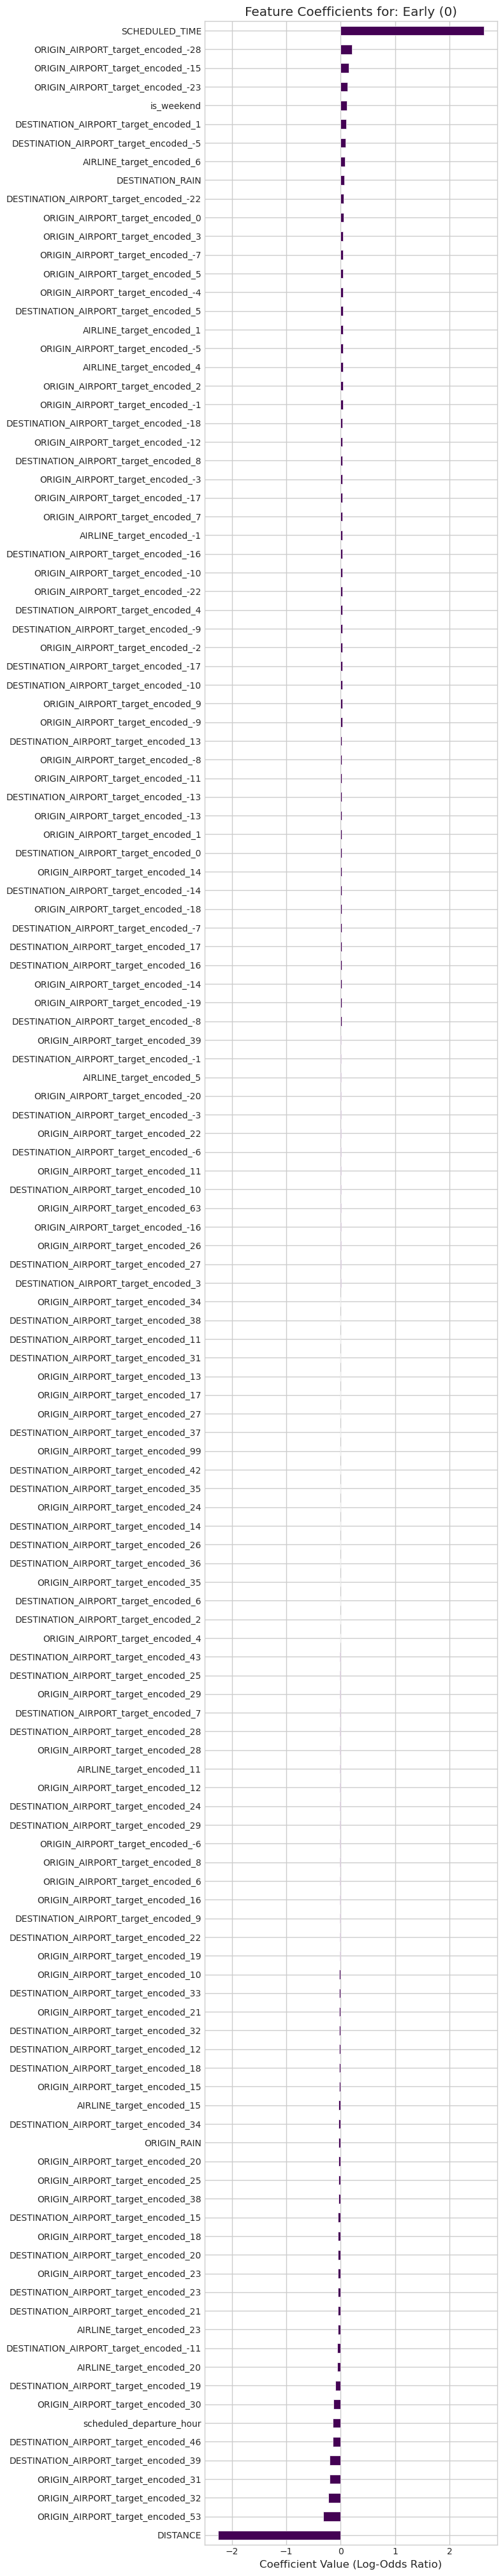

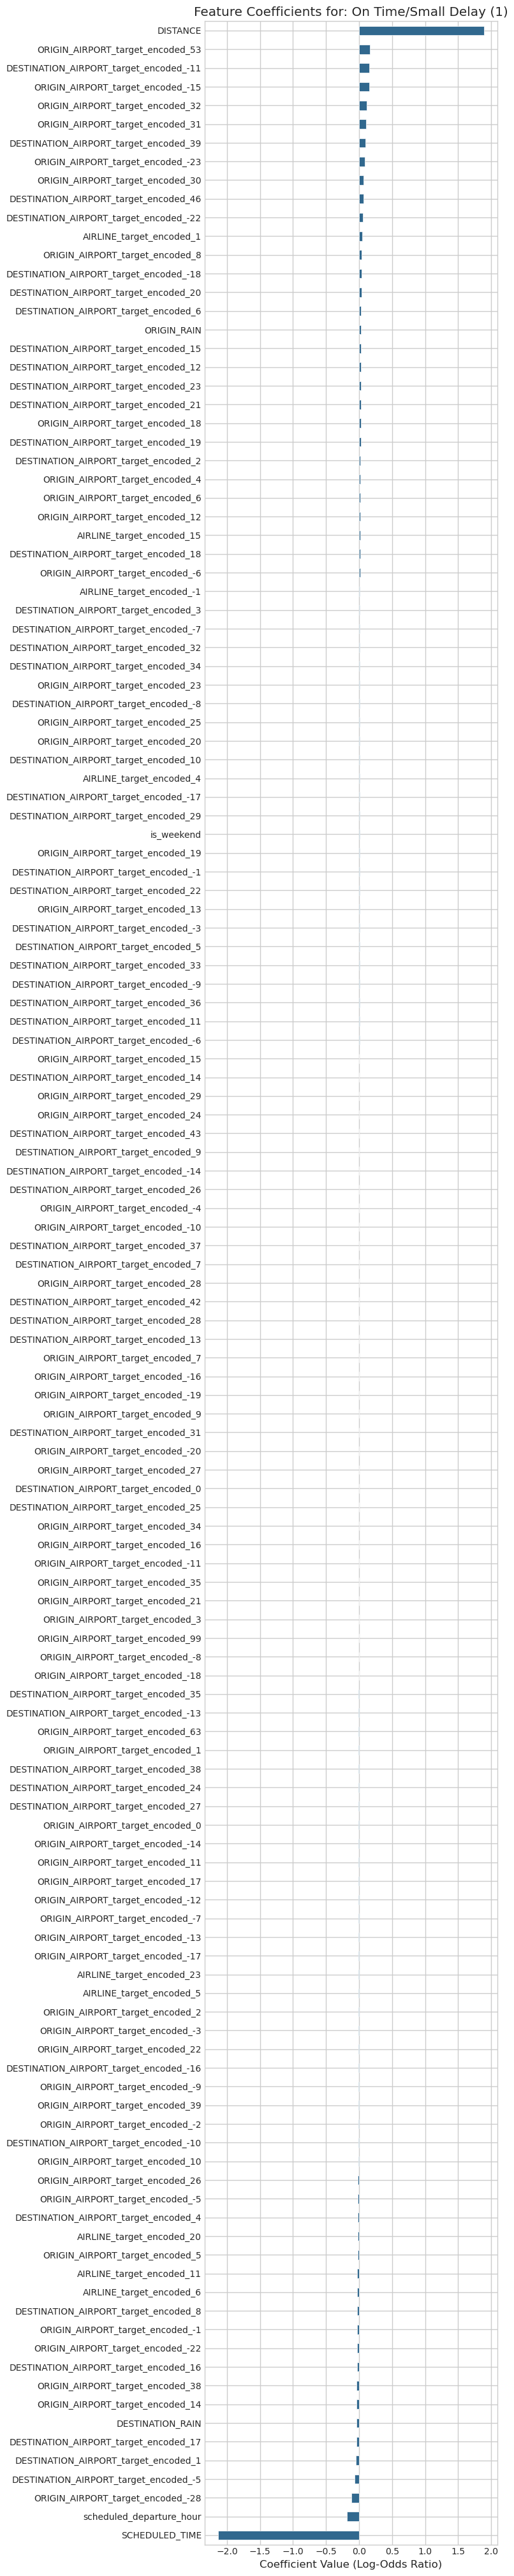

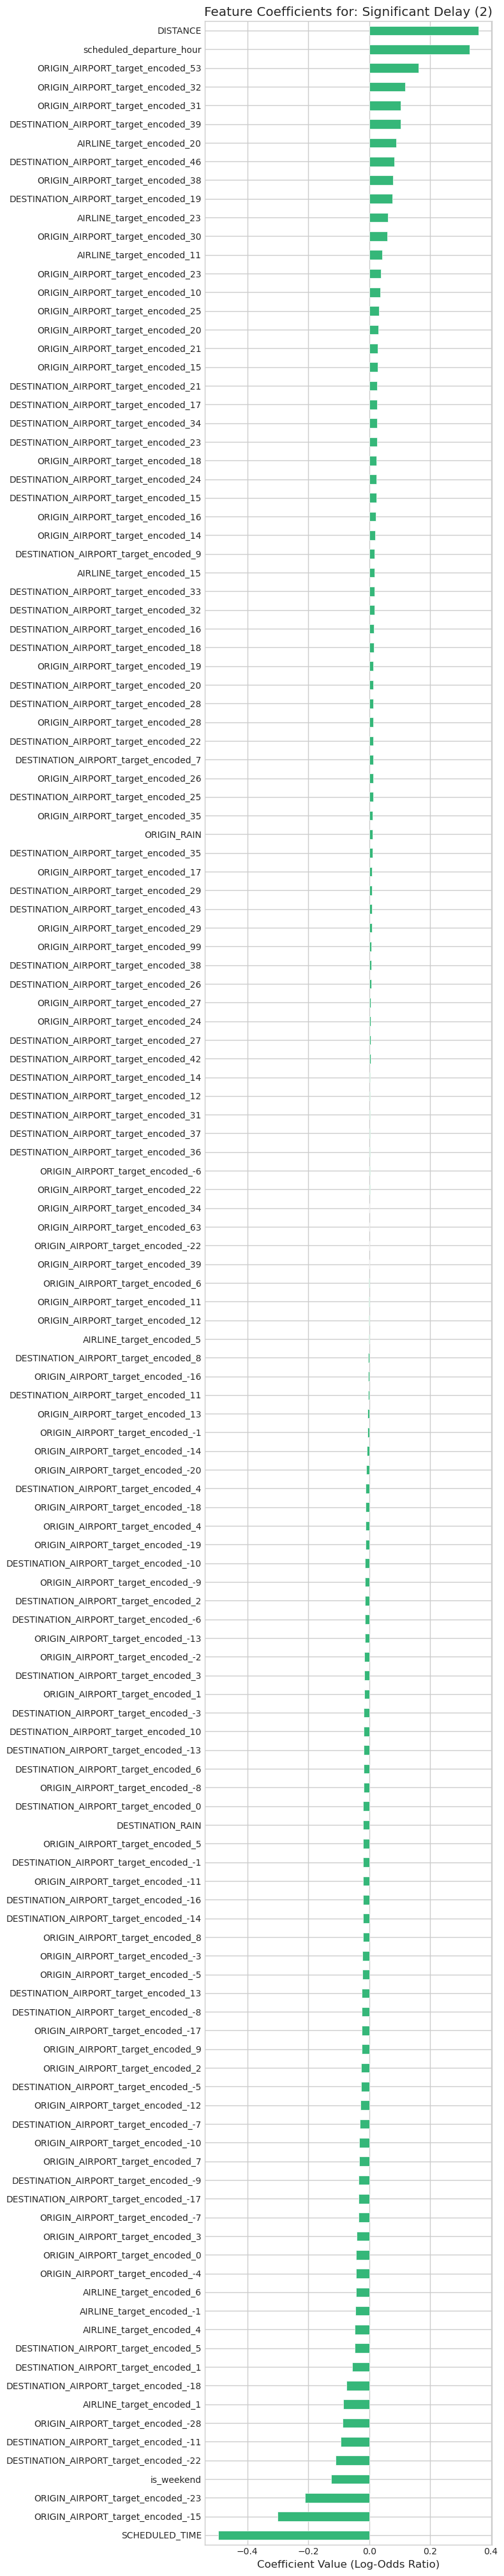

In [38]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- ASSUMPTIONS for Logistic Regression Coefficients ---
# This script assumes the following variables are ALREADY DEFINED:
#
# log_reg_multi_model: Your trained Logistic Regression model from the previous step.
# X_train_final: DataFrame with your feature columns (used to get column names).
# target_names_multi: List of your class names, 
#                     e.g., ['Early (0)', 'On Time/Small Delay (1)', 'Significant Delay (2)'].
#                     If not defined, it will try to infer from y_train_multiclass or use generic names.
# y_train_multiclass: (Optional, used to infer target_names_multi if not provided) Your training target.


print("--- Logistic Regression Coefficients ---")
coefficients = log_model.coef_ # Assumes log_reg_multi_model is defined and trained
feature_names = X_train_final.columns   # Assumes X_train_final is defined

if coefficients.shape[0] == 1: # Binary case or OvR for 2 classes handled as binary
    coef_df = pd.DataFrame(coefficients.T, index=feature_names, columns=['Coefficient'])
    print(coef_df.sort_values(by='Coefficient', ascending=False))
else: # Multi-class case
    if 'target_names_multi' not in locals() or target_names_multi is None:
        if 'y_train_multiclass' in locals() and y_train_multiclass is not None:
            unique_classes = np.sort(y_train_multiclass.unique())
            target_names_multi = [f'Class {cls}' for cls in unique_classes]
            print("Inferred target_names_multi from y_train_multiclass.")
        else:
            target_names_multi = [f'Class {i}' for i in range(coefficients.shape[0])]
            print("Used generic target_names_multi.")
            
    coef_df = pd.DataFrame(coefficients.T, index=feature_names, columns=target_names_multi)
    print(coef_df)

    for i, class_name in enumerate(target_names_multi):
        plt.figure(figsize=(8, max(4, len(feature_names)*0.3)))
        class_coeffs = coef_df[class_name].sort_values()
        class_coeffs.plot(kind='barh', color=plt.cm.viridis(i / len(target_names_multi)))
        plt.title(f'Feature Coefficients for: {class_name}')
        plt.xlabel('Coefficient Value (Log-Odds Ratio)')
        plt.tight_layout()
        plt.show()

Decision Tree Accuracy: 0.4663

Decision Tree Classification Report (Multi-class):
                         precision    recall  f1-score   support

              Early (0)       0.49      0.47      0.48      6326
On Time/Small Delay (1)       0.46      0.39      0.42      6374
  Significant Delay (2)       0.45      0.55      0.50      6314

               accuracy                           0.47     19014
              macro avg       0.47      0.47      0.46     19014
           weighted avg       0.47      0.47      0.46     19014


Decision Tree Confusion Matrix (Multi-class):


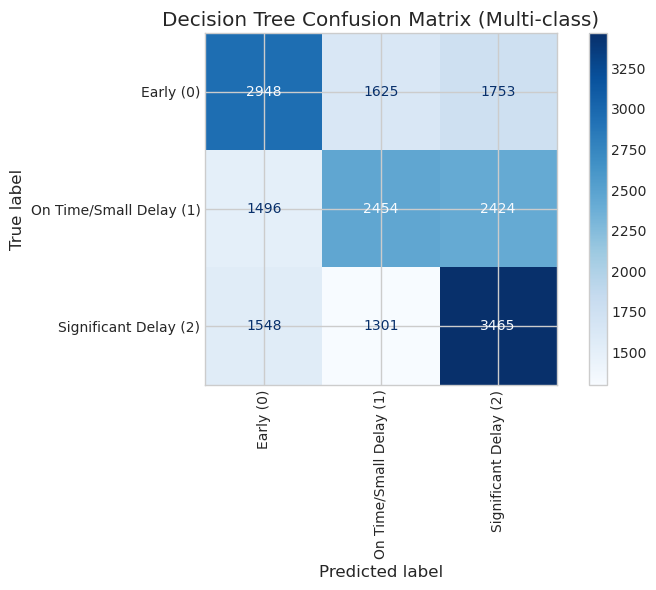


--- Feature Importances (Decision Tree) ---
                                   feature  importance
132                         SCHEDULED_TIME    0.463428
134               scheduled_departure_hour    0.358944
4                AIRLINE_target_encoded_20    0.177629
93        ORIGIN_AIRPORT_target_encoded_10    0.000000
87        ORIGIN_AIRPORT_target_encoded_-6    0.000000
..                                     ...         ...
40   DESTINATION_AIRPORT_target_encoded_23    0.000000
39   DESTINATION_AIRPORT_target_encoded_22    0.000000
38   DESTINATION_AIRPORT_target_encoded_21    0.000000
37   DESTINATION_AIRPORT_target_encoded_20    0.000000
67                                DISTANCE    0.000000

[135 rows x 2 columns]


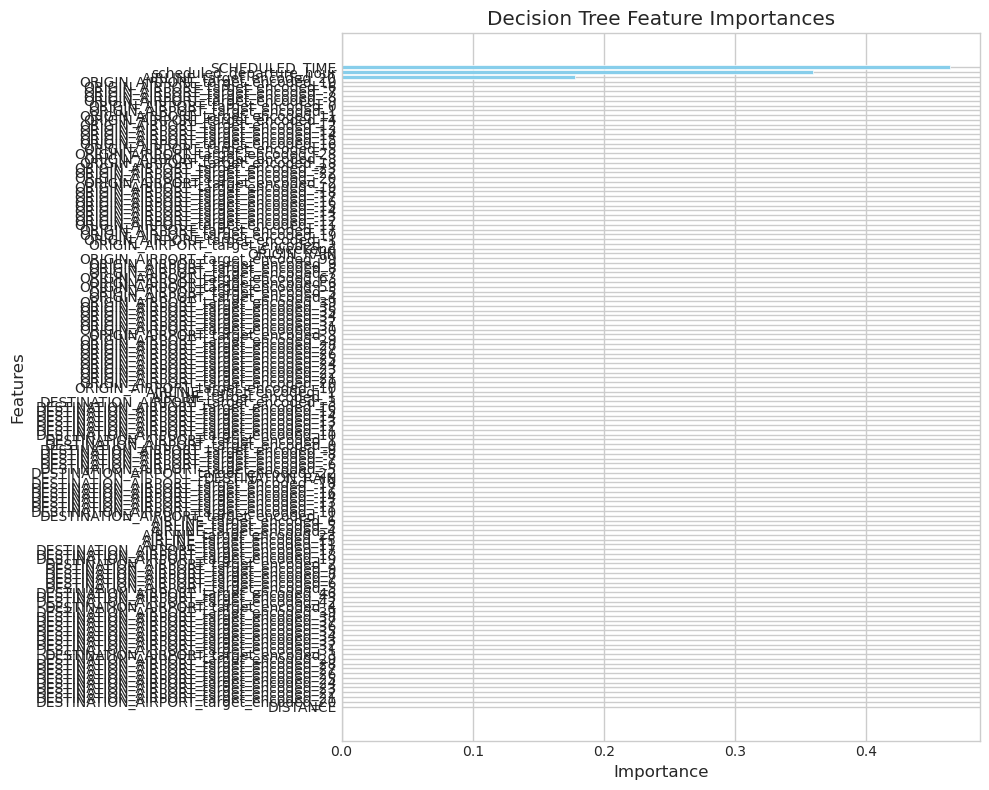

In [79]:

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_final, y_train_multiclass)


y_pred_dt_multi = dt_model.predict(X_test_final)

dt_multi_accuracy = accuracy_score(y_test_multiclass, y_pred_dt_multi)
print(f"Decision Tree Accuracy: {dt_multi_accuracy:.4f}")

print("\nDecision Tree Classification Report (Multi-class):")
# Define target names for better readability in the classification report
# Assuming 0: "Early", 1: "On Time/Small Delay", 2: "Significant Delay"
target_names_multi = ['Early (0)', 'On Time/Small Delay (1)', 'Significant Delay (2)']
print(classification_report(y_test_multiclass, y_pred_dt_multi, target_names=target_names_multi))

print("\nDecision Tree Confusion Matrix (Multi-class):")
cm_dt_multi = confusion_matrix(y_test_multiclass, y_pred_dt_multi)

# Plotting the confusion matrix
disp_dt_multi = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_multi,
    display_labels=target_names_multi # Use descriptive labels
)

fig, ax = plt.subplots(figsize=(8, 6)) # Adjust figure size
disp_dt_multi.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Decision Tree Confusion Matrix (Multi-class)")
plt.tight_layout()
plt.show()


if hasattr(dt_model, 'feature_importances_') and hasattr(X_train_final, 'columns'):
    print("\n--- Feature Importances (Decision Tree) ---")
    importances = dt_model.feature_importances_
    feature_names = X_train_final.columns
    
    if len(feature_names) == len(importances):
        feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
        feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
        print(feature_importance_df)

        # Plot feature importances
        plt.figure(figsize=(10, min(8, 0.5 * len(feature_names))))
        plt.title("Decision Tree Feature Importances")
        bars = plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color="skyblue")
        plt.xlabel("Importance")
        plt.ylabel("Features")
        plt.gca().invert_yaxis() # Display most important at the top
        plt.tight_layout()
        plt.show()
    


We observed that airline doesn't make a lot of impact so we remove it. 



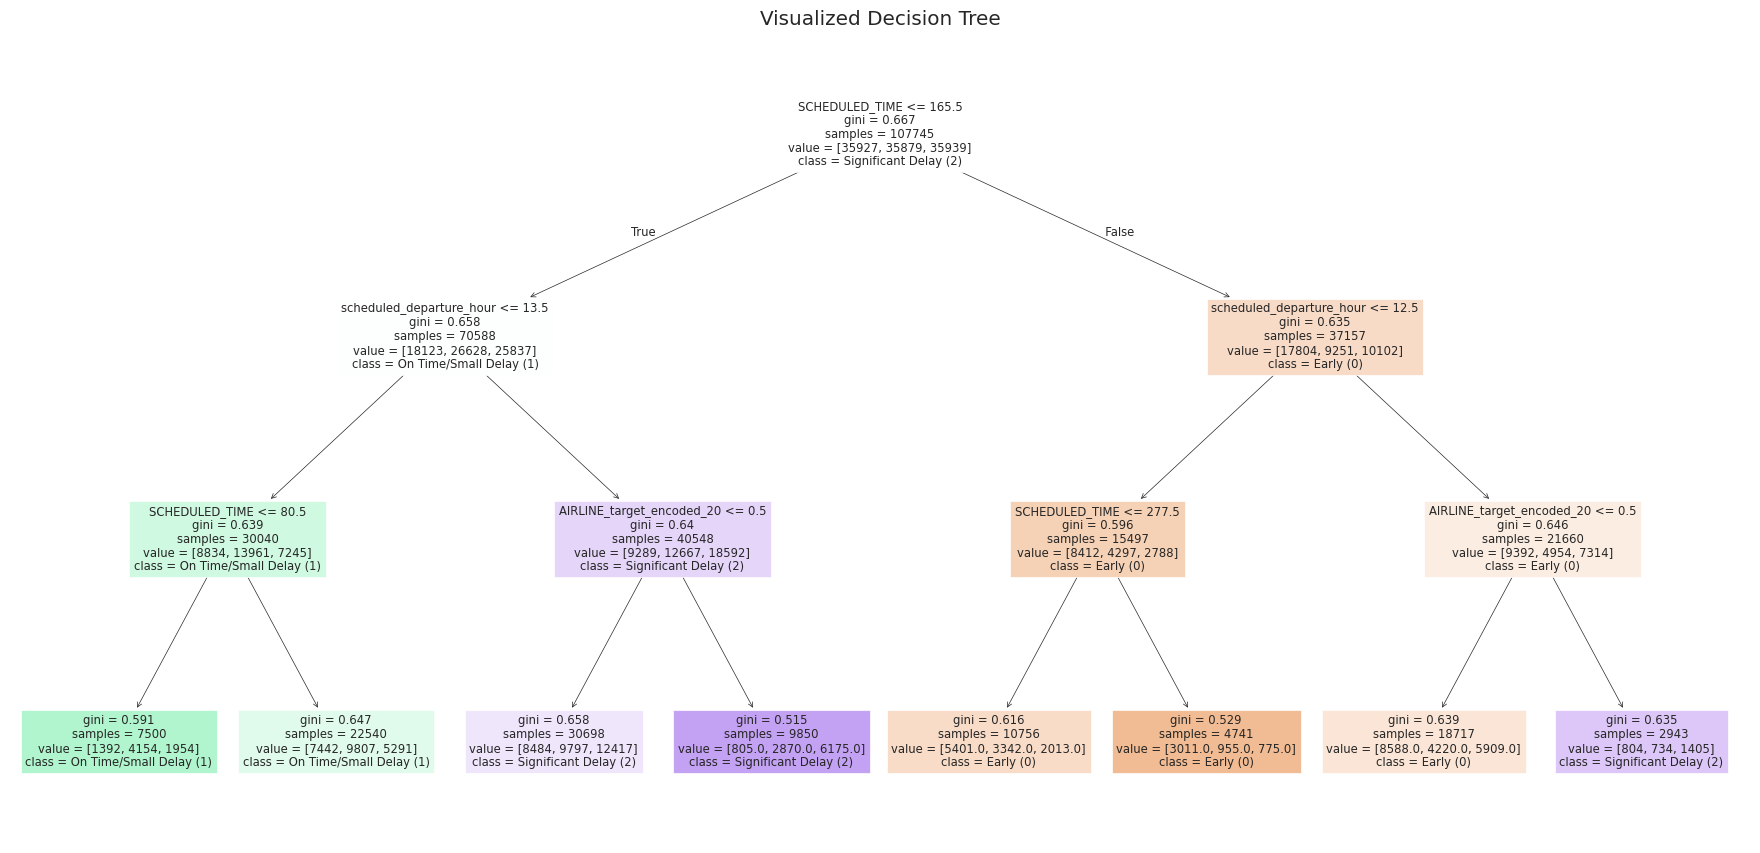

In [80]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_train_final.columns, class_names=target_names_multi, filled=True)
plt.title("Visualized Decision Tree")
plt.show()

# Implementing Bagging Tree

Training Bagging Tree model (Multi-class)...
Bagging Tree model training complete.

Making predictions with Bagging Tree on the test set...
Bagging Tree predictions made.

Evaluating Bagging Tree model (Multi-class):
Bagging Tree Accuracy: 0.5381

Bagging Tree Classification Report (Multi-class):
                         precision    recall  f1-score   support

              Early (0)       0.60      0.66      0.63      6326
On Time/Small Delay (1)       0.49      0.44      0.46      6374
  Significant Delay (2)       0.52      0.51      0.51      6314

               accuracy                           0.54     19014
              macro avg       0.53      0.54      0.54     19014
           weighted avg       0.53      0.54      0.54     19014


Bagging Tree Confusion Matrix (Multi-class):


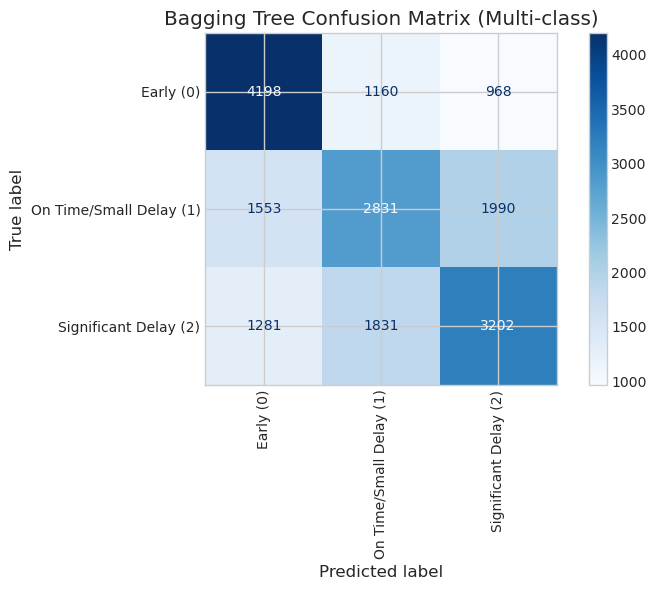

In [41]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier # Import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


base_tree = DecisionTreeClassifier(random_state=42) 

bagging_model = BaggingClassifier(
    estimator=base_tree, 
    n_estimators=50,     # Number of trees. Common to start with 10, 50, 100.
    random_state=42,
    n_jobs=-1,
    bootstrap=True       
)


print("Training Bagging Tree model (Multi-class)...")
# Using X_train_final and y_train_multiclass directly (no scaling needed for tree-based methods)
bagging_model.fit(X_train_final, y_train_multiclass)
print("Bagging Tree model training complete.")

# --- Step 2: Make Predictions on the Test Set ---
print("\nMaking predictions with Bagging Tree on the test set...")
y_pred_bagging = bagging_model.predict(X_test_final)
print("Bagging Tree predictions made.")

# --- Step 3: Evaluate the Model ---
print("\nEvaluating Bagging Tree model (Multi-class):")
bagging_accuracy = accuracy_score(y_test_multiclass, y_pred_bagging)
print(f"Bagging Tree Accuracy: {bagging_accuracy:.4f}")

print("\nBagging Tree Classification Report (Multi-class):")
# Define target names for better readability
target_names_multi = ['Early (0)', 'On Time/Small Delay (1)', 'Significant Delay (2)']
print(classification_report(y_test_multiclass, y_pred_bagging, target_names=target_names_multi))

print("\nBagging Tree Confusion Matrix (Multi-class):")
cm_bagging = confusion_matrix(y_test_multiclass, y_pred_bagging)

# Plotting the confusion matrix
disp_bagging = ConfusionMatrixDisplay(
    confusion_matrix=cm_bagging,
    display_labels=target_names_multi
)

fig, ax = plt.subplots(figsize=(8, 6))
disp_bagging.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Bagging Tree Confusion Matrix (Multi-class)")
plt.tight_layout()
plt.show()


Assuming bagging_model and X_train_final (with correct columns) are available.
Columns in X_train_final used for bagging model: ['AIRLINE_target_encoded_-1', 'AIRLINE_target_encoded_1', 'AIRLINE_target_encoded_11', 'AIRLINE_target_encoded_15', 'AIRLINE_target_encoded_20', 'AIRLINE_target_encoded_23', 'AIRLINE_target_encoded_4', 'AIRLINE_target_encoded_5', 'AIRLINE_target_encoded_6', 'DESTINATION_AIRPORT_target_encoded_-1', 'DESTINATION_AIRPORT_target_encoded_-10', 'DESTINATION_AIRPORT_target_encoded_-11', 'DESTINATION_AIRPORT_target_encoded_-13', 'DESTINATION_AIRPORT_target_encoded_-14', 'DESTINATION_AIRPORT_target_encoded_-16', 'DESTINATION_AIRPORT_target_encoded_-17', 'DESTINATION_AIRPORT_target_encoded_-18', 'DESTINATION_AIRPORT_target_encoded_-22', 'DESTINATION_AIRPORT_target_encoded_-3', 'DESTINATION_AIRPORT_target_encoded_-5', 'DESTINATION_AIRPORT_target_encoded_-6', 'DESTINATION_AIRPORT_target_encoded_-7', 'DESTINATION_AIRPORT_target_encoded_-8', 'DESTINATION_AIRPORT_target_enco

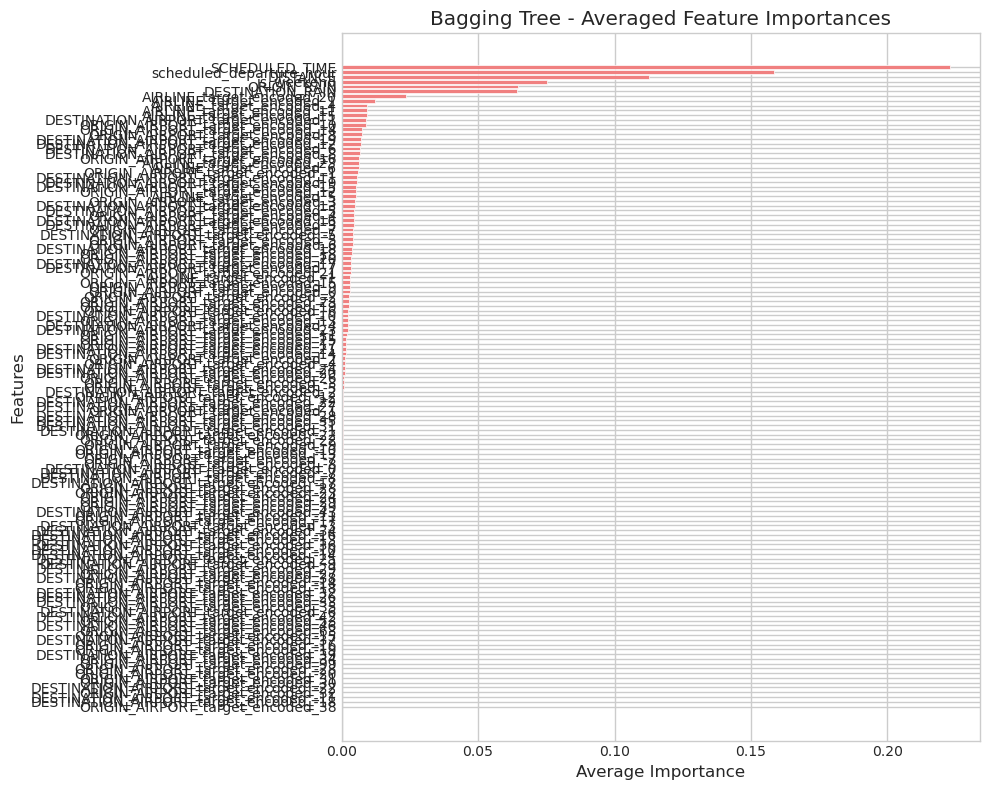

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Step 0: ASSUMPTIONS ---
# This script assumes the following variables are ALREADY DEFINED and populated:
#
# bagging_model: Your trained BaggingClassifier instance.
# X_train_final: Your training features DataFrame (all numerical), used to get feature names.
#                This should be the version AFTER 'AIRLINE_target_encoded' was removed.
#
# If any are not defined, a NameError will occur.

print("Assuming bagging_model and X_train_final (with correct columns) are available.")
print(f"Columns in X_train_final used for bagging model: {X_train_final.columns.tolist()}")


if 'bagging_model' in locals() and hasattr(bagging_model, 'estimators_') and \
   'X_train_final' in locals() and hasattr(X_train_final, 'columns'):

    # 1. Extract feature importances from each tree in the ensemble
    all_feature_importances = []
    for tree_estimator in bagging_model.estimators_:
        all_feature_importances.append(tree_estimator.feature_importances_)

    if not all_feature_importances:
        print("No base estimators found in the bagging_model or they don't have feature_importances_.")
    else:
        # 2. Average the feature importances across all trees
        avg_feature_importances = np.mean(all_feature_importances, axis=0)
        
        # 3. Get feature names
        feature_names = X_train_final.columns
        
        if len(feature_names) == len(avg_feature_importances):
            # 4. Create a DataFrame for display
            feature_importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': avg_feature_importances
            })
            feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

            print("\n--- Averaged Feature Importances (Bagging Tree Model) ---")
            print(feature_importance_df)

            # 5. Plot feature importances
            plt.figure(figsize=(10, min(8, 0.5 * len(feature_names)))) # Adjust height dynamically
            plt.title("Bagging Tree - Averaged Feature Importances")
            bars = plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color="lightcoral")
            plt.xlabel("Average Importance")
            plt.ylabel("Features")
            plt.gca().invert_yaxis() # Display most important at the top
            plt.tight_layout()
            plt.show()
        else:
            print("ERROR: Mismatch between number of feature names and calculated average importances.")
            print(f"Number of feature names: {len(feature_names)}")
            print(f"Length of average importances: {len(avg_feature_importances)}")

else:
    if 'bagging_model' not in locals() or not hasattr(bagging_model, 'estimators_'):
        print("ERROR: 'bagging_model' is not defined or not properly trained (missing 'estimators_').")
    if 'X_train_final' not in locals() or not hasattr(X_train_final, 'columns'):
        print("ERROR: 'X_train_final' (with columns attribute) is not defined. Cannot get feature names.")

In [43]:
y_train_multiclass

61041     1.0
54082     2.0
110742    2.0
90656     1.0
43718     1.0
         ... 
119879    2.0
103694    0.0
860       0.0
15795     0.0
121958    0.0
Name: ARRIVAL_DELAY_MULTICLASS, Length: 107745, dtype: float64

In [44]:
X_train_final

,AIRLINE_target_encoded_-1,AIRLINE_target_encoded_1,AIRLINE_target_encoded_11,AIRLINE_target_encoded_15,AIRLINE_target_encoded_20,AIRLINE_target_encoded_23,AIRLINE_target_encoded_4,AIRLINE_target_encoded_5,AIRLINE_target_encoded_6,DESTINATION_AIRPORT_target_encoded_-1,DESTINATION_AIRPORT_target_encoded_-10,DESTINATION_AIRPORT_target_encoded_-11,DESTINATION_AIRPORT_target_encoded_-13,DESTINATION_AIRPORT_target_encoded_-14,DESTINATION_AIRPORT_target_encoded_-16,DESTINATION_AIRPORT_target_encoded_-17,DESTINATION_AIRPORT_target_encoded_-18,DESTINATION_AIRPORT_target_encoded_-22,DESTINATION_AIRPORT_target_encoded_-3,DESTINATION_AIRPORT_target_encoded_-5,DESTINATION_AIRPORT_target_encoded_-6,DESTINATION_AIRPORT_target_encoded_-7,DESTINATION_AIRPORT_target_encoded_-8,DESTINATION_AIRPORT_target_encoded_-9,DESTINATION_AIRPORT_target_encoded_0,...,ORIGIN_AIRPORT_target_encoded_26,ORIGIN_AIRPORT_target_encoded_27,ORIGIN_AIRPORT_target_encoded_28,ORIGIN_AIRPORT_target_encoded_29,ORIGIN_AIRPORT_target_encoded_3,ORIGIN_AIRPORT_target_encoded_30,ORIGIN_AIRPORT_target_encoded_31,ORIGIN_AIRPORT_target_encoded_32,ORIGIN_AIRPORT_target_encoded_34,ORIGIN_AIRPORT_target_encoded_35,ORIGIN_AIRPORT_target_encoded_38,ORIGIN_AIRPORT_target_encoded_39,ORIGIN_AIRPORT_target_encoded_4,ORIGIN_AIRPORT_target_encoded_5,ORIGIN_AIRPORT_target_encoded_53,ORIGIN_AIRPORT_target_encoded_6,ORIGIN_AIRPORT_target_encoded_63,ORIGIN_AIRPORT_target_encoded_7,ORIGIN_AIRPORT_target_encoded_8,ORIGIN_AIRPORT_target_encoded_9,ORIGIN_AIRPORT_target_encoded_99,ORIGIN_RAIN,SCHEDULED_TIME,is_weekend,scheduled_departure_hour
61041,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,27.1,104.0,1,20
54082,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.9,110.0,0,21
110742,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,8.9,259.0,0,12
90656,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.3,250.0,0,11
43718,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,127.4,199.0,0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,8.9,111.0,1,17
103694,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.0,122.0,0,10
860,False,False,False,False,True,False,False,False,False,False,False,False,False,False,F

In [45]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Create a pipeline with scaling + KNN
knn_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Standardize features
    ('PCA', PCA(n_components=30)),
    ('knn', KNeighborsClassifier(n_neighbors=10))  # You can also tune k
])

# Fit the model
knn_pca_pipeline.fit(X_train_final, y_train_multiclass)

Pipeline(steps=[('scaler', StandardScaler()), ('PCA', PCA(n_components=30)),
                ('knn', KNeighborsClassifier(n_neighbors=10))])

Classification Report:
              precision    recall  f1-score   support

       Early       0.58      0.71      0.64      6326
    Punctual       0.50      0.45      0.47      6374
        Late       0.53      0.47      0.50      6314

    accuracy                           0.54     19014
   macro avg       0.54      0.54      0.54     19014
weighted avg       0.54      0.54      0.54     19014

Confusion Matrix:
[[4481 1005  840]
 [1779 2864 1731]
 [1521 1850 2943]]
Confusion Matrix:
[[4481 1005  840]
 [1779 2864 1731]
 [1521 1850 2943]]


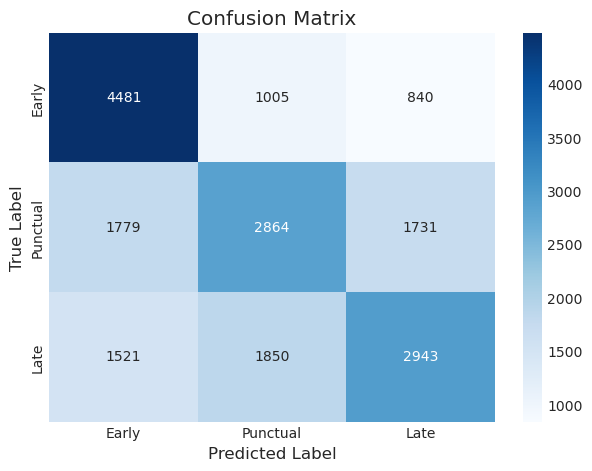

In [46]:
y_pred = knn_pca_pipeline.predict(X_test_final)

# Evaluate
print("Classification Report:")
print(classification_report(y_test_multiclass, y_pred, target_names=['Early', 'Punctual', 'Late']))

print("Confusion Matrix:")
print(confusion_matrix(y_test_multiclass, y_pred))

cm = confusion_matrix(y_test_multiclass, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: visualize with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early', 'Punctual', 'Late'],
            yticklabels=['Early', 'Punctual', 'Late'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [47]:
import xgboost as xgb

In [48]:
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',   # Note: correct metric name is 'mlogloss' not 'malogloss'
    use_label_encoder=False,
    random_state=42,
    learning_rate=0.01,
    max_depth=10,
    n_estimators=500,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=1,
    scale_pos_weight=None,  # For class imbalance, can set or use class weights if needed
    n_jobs=-1,
)

model.fit(X_train_final, y_train_multiclass)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=3, ...)

In [49]:
y_probs = model.predict_proba(X_test_final)
y_pred = np.argmax(y_probs, axis=1)

print(classification_report(y_test_multiclass, y_pred))
print(confusion_matrix(y_test_multiclass, y_pred))

              precision    recall  f1-score   support

         0.0       0.60      0.72      0.65      6326
         1.0       0.55      0.46      0.50      6374
         2.0       0.56      0.54      0.55      6314

    accuracy                           0.57     19014
   macro avg       0.57      0.57      0.57     19014
weighted avg       0.57      0.57      0.57     19014

[[4525  905  896]
 [1624 2931 1819]
 [1397 1478 3439]]


In [50]:
cost_matrix = np.array([
    [0, 1, 3],  # true early: cost 0 if predicted early, 1 if punctual, 5 if late
    [1, 0, 2],  # true punctual
    [3, 1, 0]   # true late
])

# Calculate expected cost for each predicted class
expected_costs = y_probs @ cost_matrix

# Predict class with minimum expected cost
y_pred_cost_sensitive = np.argmin(expected_costs, axis=1)

print("Cost-sensitive classification report:")
print(classification_report(y_test_multiclass, y_pred_cost_sensitive))
print(confusion_matrix(y_test_multiclass, y_pred_cost_sensitive))

Cost-sensitive classification report:
              precision    recall  f1-score   support

         0.0       0.73      0.30      0.42      6326
         1.0       0.37      0.91      0.53      6374
         2.0       0.76      0.10      0.18      6314

    accuracy                           0.44     19014
   macro avg       0.62      0.44      0.38     19014
weighted avg       0.62      0.44      0.38     19014

[[1889 4422   15]
 [ 416 5772  186]
 [ 289 5377  648]]


Confusion Matrix:
[[4525  905  896]
 [1624 2931 1819]
 [1397 1478 3439]]


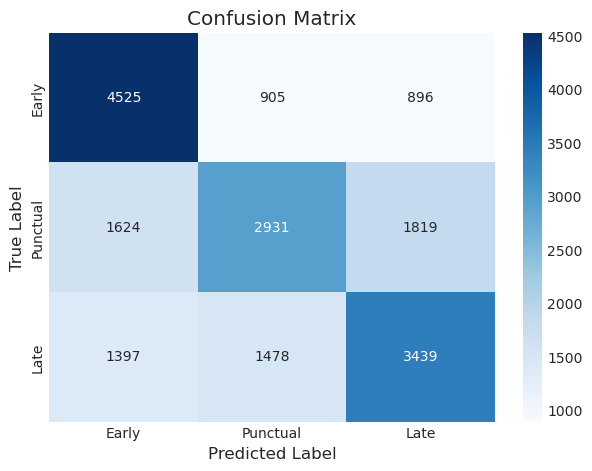

In [51]:
cm = confusion_matrix(y_test_multiclass, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: visualize with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early', 'Punctual', 'Late'],
            yticklabels=['Early', 'Punctual', 'Late'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [52]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Define your class weights, e.g. more weight for early (0) and late (2)
class_weights = {0: 1.2, 1: 1.0, 2: 1.2}

# Initialize the LightGBM classifier with class weights
model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    class_weight=class_weights,
    learning_rate=0.1,
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Fit the model
model.fit(X_train_final, y_train_multiclass)

# Predict on test/validation set
y_pred = model.predict(X_test_final)

# Print classification report
print(classification_report(y_test_multiclass, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034689 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1205
[LightGBM] [Info] Number of data points in the train set: 107745, number of used features: 115
[LightGBM] [Info] Start training from score -1.041179
[LightGBM] [Info] Start training from score -1.224837
[LightGBM] [Info] Start training from score -1.040845
              precision    recall  f1-score   support

         0.0       0.57      0.74      0.64      6326
         1.0       0.58      0.36      0.44      6374
         2.0       0.53      0.57      0.55      6314

    accuracy                           0.56     19014
   macro avg       0.56      0.56      0.54     19014
weighted avg       0.56      0.56      0.54     19014



Confusion Matrix:
[[4658  641 1027]
 [1932 2273 2169]
 [1654 1034 3626]]


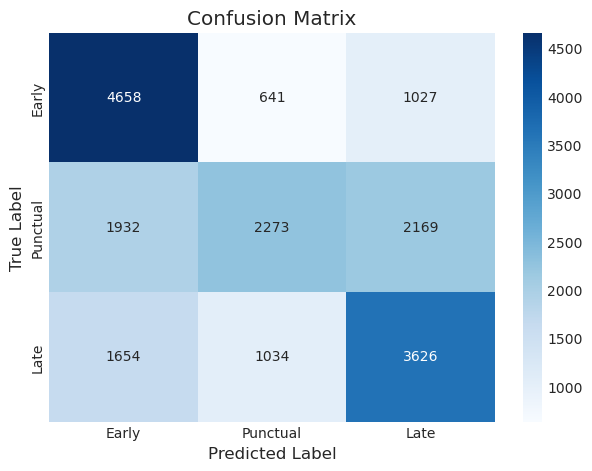

In [53]:
cm = confusion_matrix(y_test_multiclass, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: visualize with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early', 'Punctual', 'Late'],
            yticklabels=['Early', 'Punctual', 'Late'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [54]:
X_test_final1 = X_test_final.copy()
X_test_final1['DEP_DELAY'] = df['ARRIVAL_DELAY']

y_test = (X_test_final1['DEP_DELAY'] > -15).astype(int)

X_test_final1 = X_test_final1.drop(columns=['DEP_DELAY'])
X_test_final1

,AIRLINE_target_encoded_-1,AIRLINE_target_encoded_1,AIRLINE_target_encoded_11,AIRLINE_target_encoded_15,AIRLINE_target_encoded_20,AIRLINE_target_encoded_23,AIRLINE_target_encoded_4,AIRLINE_target_encoded_5,AIRLINE_target_encoded_6,DESTINATION_AIRPORT_target_encoded_-1,DESTINATION_AIRPORT_target_encoded_-10,DESTINATION_AIRPORT_target_encoded_-11,DESTINATION_AIRPORT_target_encoded_-13,DESTINATION_AIRPORT_target_encoded_-14,DESTINATION_AIRPORT_target_encoded_-16,DESTINATION_AIRPORT_target_encoded_-17,DESTINATION_AIRPORT_target_encoded_-18,DESTINATION_AIRPORT_target_encoded_-22,DESTINATION_AIRPORT_target_encoded_-3,DESTINATION_AIRPORT_target_encoded_-5,DESTINATION_AIRPORT_target_encoded_-6,DESTINATION_AIRPORT_target_encoded_-7,DESTINATION_AIRPORT_target_encoded_-8,DESTINATION_AIRPORT_target_encoded_-9,DESTINATION_AIRPORT_target_encoded_0,...,ORIGIN_AIRPORT_target_encoded_26,ORIGIN_AIRPORT_target_encoded_27,ORIGIN_AIRPORT_target_encoded_28,ORIGIN_AIRPORT_target_encoded_29,ORIGIN_AIRPORT_target_encoded_3,ORIGIN_AIRPORT_target_encoded_30,ORIGIN_AIRPORT_target_encoded_31,ORIGIN_AIRPORT_target_encoded_32,ORIGIN_AIRPORT_target_encoded_34,ORIGIN_AIRPORT_target_encoded_35,ORIGIN_AIRPORT_target_encoded_38,ORIGIN_AIRPORT_target_encoded_39,ORIGIN_AIRPORT_target_encoded_4,ORIGIN_AIRPORT_target_encoded_5,ORIGIN_AIRPORT_target_encoded_53,ORIGIN_AIRPORT_target_encoded_6,ORIGIN_AIRPORT_target_encoded_63,ORIGIN_AIRPORT_target_encoded_7,ORIGIN_AIRPORT_target_encoded_8,ORIGIN_AIRPORT_target_encoded_9,ORIGIN_AIRPORT_target_encoded_99,ORIGIN_RAIN,SCHEDULED_TIME,is_weekend,scheduled_departure_hour
123281,False,False,False,False,False,True,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,True,False,False,11.6,255.0,0,7
18664,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,86.5,45.0,1,14
6697,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,True,False,False,23.4,97.0,0,17
30441,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,True,False,False,False,False,False,False,False,False,53.1,165.0,0,13
7751,False,False,False,False,True,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,8.9,60.0,0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18554,False,False,False,True,False,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,128.2,177.0,0,21
70260,False,False,False,False,True,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,88.6,65.0,0,21
19030,False,False,False,False,True,False,False,False,False,False,False,0,False,False,False,False,0,False,False,False,False,False,False,False,False,...,False,False,False,False,Fals

In [55]:
X_train_final1 = X_train_final.copy()
X_train_final1['DEP_DELAY'] = df['ARRIVAL_DELAY']

y_train = (X_train_final1['DEP_DELAY'] > -15).astype(int)

X_train_final1 = X_train_final1.drop(columns=['DEP_DELAY'])
X_train_final1

,AIRLINE_target_encoded_-1,AIRLINE_target_encoded_1,AIRLINE_target_encoded_11,AIRLINE_target_encoded_15,AIRLINE_target_encoded_20,AIRLINE_target_encoded_23,AIRLINE_target_encoded_4,AIRLINE_target_encoded_5,AIRLINE_target_encoded_6,DESTINATION_AIRPORT_target_encoded_-1,DESTINATION_AIRPORT_target_encoded_-10,DESTINATION_AIRPORT_target_encoded_-11,DESTINATION_AIRPORT_target_encoded_-13,DESTINATION_AIRPORT_target_encoded_-14,DESTINATION_AIRPORT_target_encoded_-16,DESTINATION_AIRPORT_target_encoded_-17,DESTINATION_AIRPORT_target_encoded_-18,DESTINATION_AIRPORT_target_encoded_-22,DESTINATION_AIRPORT_target_encoded_-3,DESTINATION_AIRPORT_target_encoded_-5,DESTINATION_AIRPORT_target_encoded_-6,DESTINATION_AIRPORT_target_encoded_-7,DESTINATION_AIRPORT_target_encoded_-8,DESTINATION_AIRPORT_target_encoded_-9,DESTINATION_AIRPORT_target_encoded_0,...,ORIGIN_AIRPORT_target_encoded_26,ORIGIN_AIRPORT_target_encoded_27,ORIGIN_AIRPORT_target_encoded_28,ORIGIN_AIRPORT_target_encoded_29,ORIGIN_AIRPORT_target_encoded_3,ORIGIN_AIRPORT_target_encoded_30,ORIGIN_AIRPORT_target_encoded_31,ORIGIN_AIRPORT_target_encoded_32,ORIGIN_AIRPORT_target_encoded_34,ORIGIN_AIRPORT_target_encoded_35,ORIGIN_AIRPORT_target_encoded_38,ORIGIN_AIRPORT_target_encoded_39,ORIGIN_AIRPORT_target_encoded_4,ORIGIN_AIRPORT_target_encoded_5,ORIGIN_AIRPORT_target_encoded_53,ORIGIN_AIRPORT_target_encoded_6,ORIGIN_AIRPORT_target_encoded_63,ORIGIN_AIRPORT_target_encoded_7,ORIGIN_AIRPORT_target_encoded_8,ORIGIN_AIRPORT_target_encoded_9,ORIGIN_AIRPORT_target_encoded_99,ORIGIN_RAIN,SCHEDULED_TIME,is_weekend,scheduled_departure_hour
61041,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,27.1,104.0,1,20
54082,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.9,110.0,0,21
110742,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,8.9,259.0,0,12
90656,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.3,250.0,0,11
43718,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,127.4,199.0,0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,8.9,111.0,1,17
103694,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.0,122.0,0,10
860,False,False,False,False,True,False,False,False,False,False,False,False,False,False,F

In [56]:
X_df = pd.DataFrame(X_train_final1)
y_series = pd.Series(y_train)

# Find indices of each class
indices_0 = y_series[y_series == 0].index
indices_1 = y_series[y_series == 1].index

# Determine the number to sample — minimum of the two class sizes
n_samples = min(len(indices_0), len(indices_1))

# Randomly sample from each class
sampled_0 = np.random.choice(indices_0, size=n_samples, replace=False)
sampled_1 = np.random.choice(indices_1, size=n_samples, replace=False)

# Combine and shuffle the indices
balanced_indices = np.concatenate([sampled_0, sampled_1])
np.random.shuffle(balanced_indices)

# Apply to X and y
X_train_final1 = X_df.loc[balanced_indices].reset_index(drop=True)
y_train = y_series.loc[balanced_indices].reset_index(drop=True)

In [57]:
y_train

0        0
1        0
2        1
3        1
4        0
        ..
83321    0
83322    0
83323    0
83324    0
83325    0
Name: DEP_DELAY, Length: 83326, dtype: int64

In [58]:
y_test

123281    1
18664     1
6697      1
30441     1
7751      1
         ..
18554     1
70260     1
19030     1
70738     0
102822    1
Name: DEP_DELAY, Length: 19014, dtype: int64

In [59]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_final1, y_train)

LogisticRegression(max_iter=1000, random_state=42)

              precision    recall  f1-score   support

           0       0.61      0.75      0.67      7390
           1       0.81      0.70      0.75     11624

    accuracy                           0.72     19014
   macro avg       0.71      0.72      0.71     19014
weighted avg       0.74      0.72      0.72     19014

Confusion Matrix:
[[5533 1857]
 [3490 8134]]


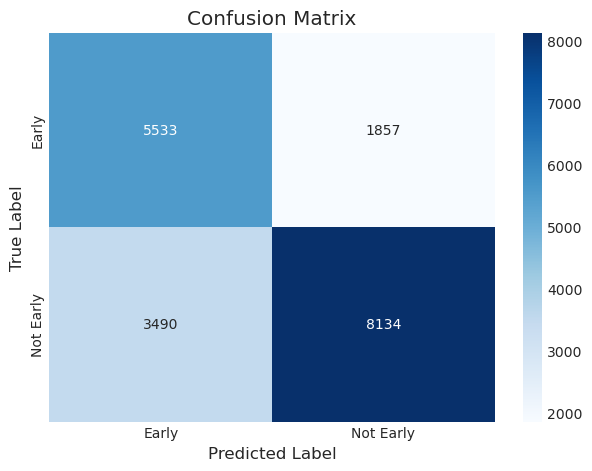

In [72]:
y_pred = clf.predict(X_test_final1)

# 4) Predict probabilities (probability of class 1)
y_probs = clf.predict_proba(X_test_final1)[:, 1]

# 5) Evaluation
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: visualize with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early', 'Not Early'],
            yticklabels=['Early', 'Not Early'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Initialize and train the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_final1, y_train)

# Predict class probabilities
y_probs = clf.predict_proba(X_test_final1)  # Returns array of shape (n_samples, 2)

# Predict classes (optional)
y_pred = clf.predict(X_test_final1)

# Show evaluation
print(classification_report(y_test, y_pred))

# Example: show first 5 predicted probabilities of being delayed (class 1)
print("Delay probabilities for first 5 flights:")

y_probs

              precision    recall  f1-score   support

           0       0.61      0.75      0.67      7390
           1       0.81      0.70      0.75     11624

    accuracy                           0.72     19014
   macro avg       0.71      0.72      0.71     19014
weighted avg       0.74      0.72      0.72     19014

Delay probabilities for first 5 flights:


array([[0.02533333, 0.97466667],
       [0.025     , 0.975     ],
       [0.00333333, 0.99666667],
       ...,
       [0.32770635, 0.67229365],
       [0.81551984, 0.18448016],
       [0.        , 1.        ]])

In [62]:
y_probs1 = clf.predict_proba(X_train_final)
y_probs1

array([[0.07716667, 0.92283333],
       [0.31366919, 0.68633081],
       [0.57357395, 0.42642605],
       ...,
       [0.63640548, 0.36359452],
       [0.20126984, 0.79873016],
       [0.76324083, 0.23675917]])

In [63]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Create a pipeline with scaling + KNN
knn_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Standardize features
    ('pca', PCA(n_components=20)),
    ('knn', KNeighborsClassifier(n_neighbors=5))  # You can also tune k
])

# Fit the model
knn_pca_pipeline.fit(X_train_final1, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=20)),
                ('knn', KNeighborsClassifier())])

Classification Report:
                  precision    recall  f1-score   support

           Early       0.61      0.75      0.67      7390
Punctual or Late       0.81      0.69      0.75     11624

        accuracy                           0.71     19014
       macro avg       0.71      0.72      0.71     19014
    weighted avg       0.73      0.71      0.72     19014

Confusion Matrix:
[[5510 1880]
 [3583 8041]]
Confusion Matrix:
[[5510 1880]
 [3583 8041]]


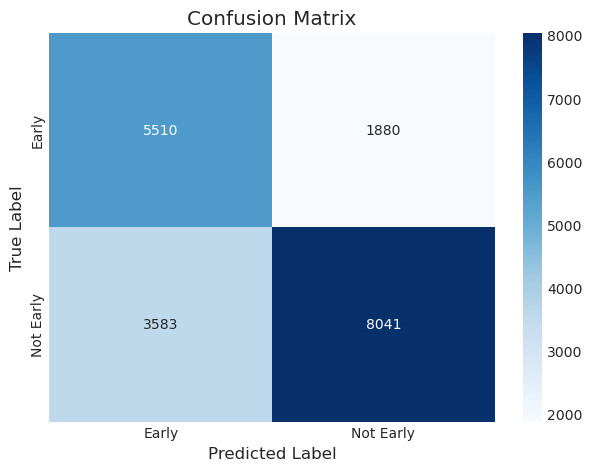

In [76]:
y_pred = knn_pca_pipeline.predict(X_test_final1)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Early', 'Punctual or Late']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: visualize with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early', 'Not Early'],
            yticklabels=['Early', 'Not Early'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.61      0.75      0.67      7390
           1       0.82      0.70      0.75     11624

    accuracy                           0.72     19014
   macro avg       0.71      0.72      0.71     19014
weighted avg       0.74      0.72      0.72     19014

Delay probabilities for first 5 flights:
[0.97833333 1.         0.99       0.80929293 1.        ]
Confusion Matrix:
[[5552 1838]
 [3523 8101]]


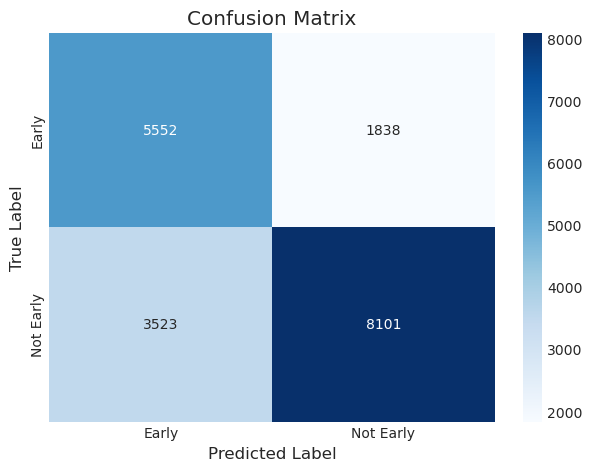

In [77]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize base estimator (a decision tree)
base_tree = DecisionTreeClassifier(random_state=42)

# Initialize Bagging classifier
bagging_clf = BaggingClassifier(
    estimator=base_tree,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit the model
bagging_clf.fit(X_train_final1, y_train)

# Predict class probabilities
y_probs = bagging_clf.predict_proba(X_test_final1)

# Predict class labels
y_pred = bagging_clf.predict(X_test_final1)

# Evaluation
print(classification_report(y_test, y_pred))

# Print first 5 probability scores for the positive class (class 1)
print("Delay probabilities for first 5 flights:")
print(y_probs[:5, 1])

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: visualize with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early', 'Not Early'],
            yticklabels=['Early', 'Not Early'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.62      0.78      0.69      7390
           1       0.83      0.69      0.76     11624

    accuracy                           0.73     19014
   macro avg       0.72      0.74      0.72     19014
weighted avg       0.75      0.73      0.73     19014

Delay probabilities for first 5 flights:
[0.73335475 0.924123   0.75786173 0.5484487  0.9808399 ]
Confusion Matrix:
[[5745 1645]
 [3549 8075]]


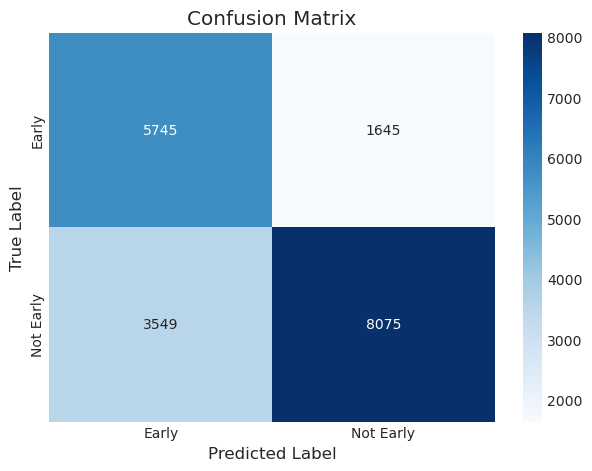

In [78]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Binary classification model setup
model = xgb.XGBClassifier(
    objective='binary:logistic',      # Binary classification
    eval_metric='logloss',            # For binary targets
    use_label_encoder=False,
    random_state=42,
    learning_rate=0.01,
    max_depth=10,
    n_estimators=500,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=1,
    scale_pos_weight=None,            # Optional: useful if you have class imbalance
    n_jobs=-1
)

# Train the model
model.fit(X_train_final1, y_train)

# Predict class probabilities
y_probs = model.predict_proba(X_test_final1)

# Predict class labels
y_pred = model.predict(X_test_final1)

# Evaluation
print(classification_report(y_test, y_pred))

# Show first 5 predicted probabilities for positive class (1 = delayed)
print("Delay probabilities for first 5 flights:")
print(y_probs[:5, 1])

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Optional: visualize with a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Early', 'Not Early'],
            yticklabels=['Early', 'Not Early'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()